# Benchmark 1D 

Example of creation of a multifidelity Neural Network to create the model that connects the input variables to the function itself. After that, it is possible to build a Markov Chain Monte Carlo alogoritm to discover the original input value, considered in general unknown. 

In this case, we are facing a Discontinuous function

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


Ray module not found. Multiprocessing features are not available


True

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

# Creation of the model

In [3]:
#Benchmark1
lowfid = lambda x: (0.5*(6.*x/5.-2.)**2*np.sin(12.*x/5.-4)+10.*(x/5-0.5)-5.)*(x<2.5) + (3+0.5*(6.*x/5.-2)**2*np.sin(12.*x/5.-4)+10*(x/5.-0.5)-5.)*(x>2.5)
highfid = lambda x: (2*lowfid(x)- 20*x/5.+20)*(x/5.<0.5) + (4+2*lowfid(x)- 20*x/5.+20)*(x/5.>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

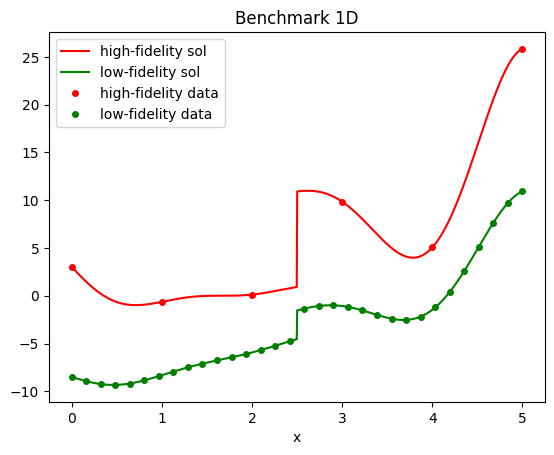

In [4]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model




The function training took 11.170156955718994 seconds.


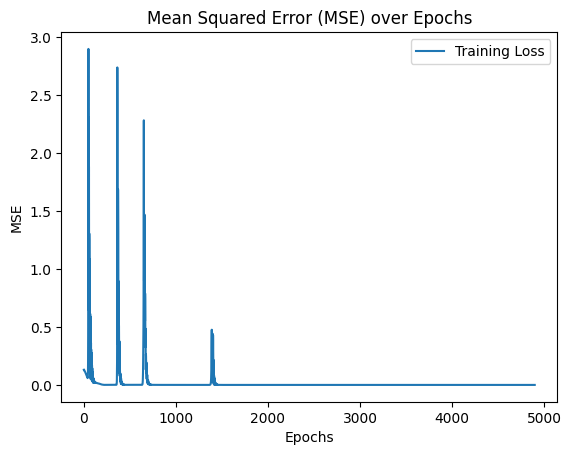

Test MSE: 82.28460495445167
R^2: -0.6799809348550425


In [5]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test))

## High fidelity model

The function training took 3.1982696056365967 seconds.


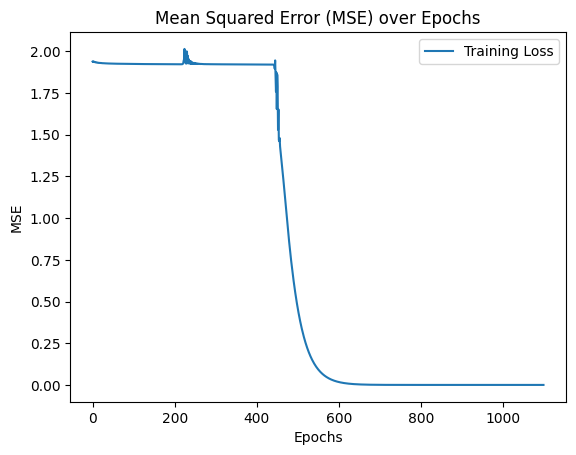

Test MSE: 3.500971987214512
R^2: 0.9285216694515618


In [6]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test))

## 2 Step model

The function training took 11.617963314056396 seconds.


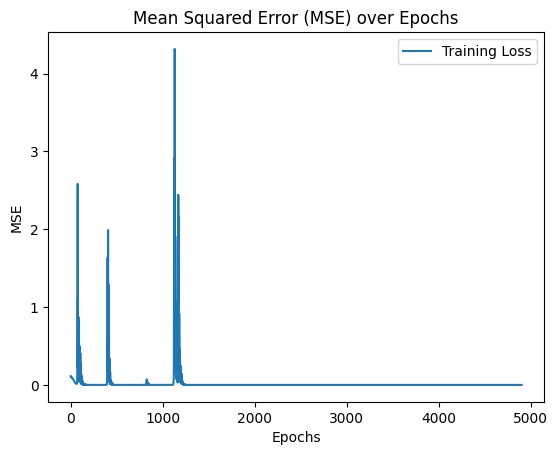

The function training took 2.715397596359253 seconds.


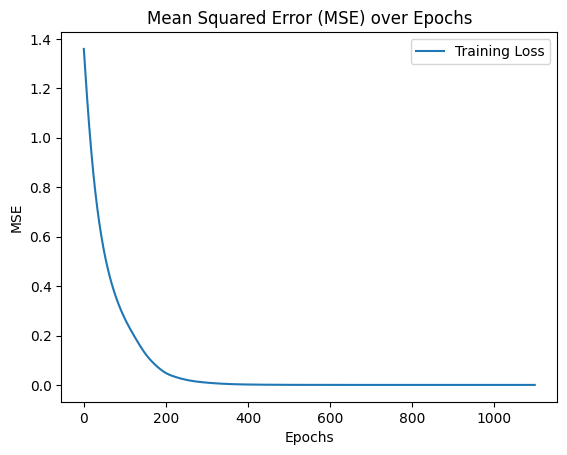

Test MSE: 5.638232328092625
R^2: 0.8848858444088997


In [7]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

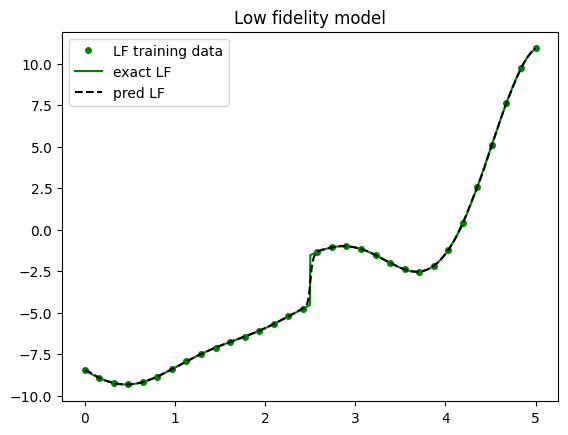

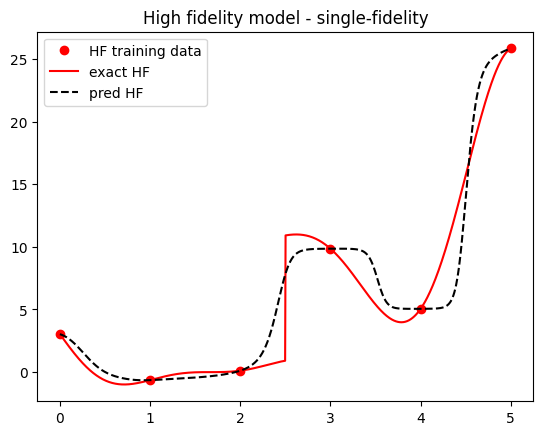

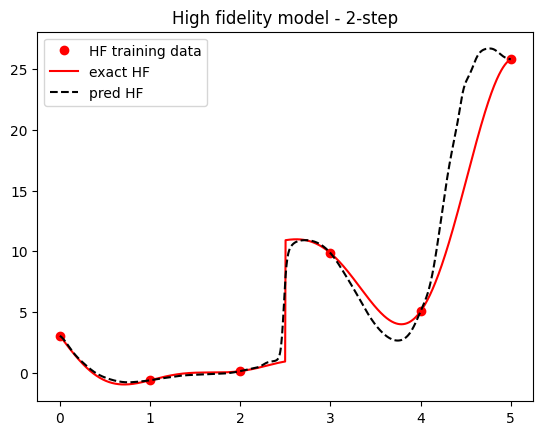

In [8]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [15]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([1.,2.,3.,4.])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.9
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=4

real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.11: 100%|██████████| 2000/2000 [03:13<00:00, 10.34it/s]


Sampling chain 2/4


Running chain, α = 0.13: 100%|██████████| 2000/2000 [03:00<00:00, 11.07it/s]


Sampling chain 3/4


Running chain, α = 0.39: 100%|██████████| 2000/2000 [02:53<00:00, 11.50it/s]


Sampling chain 4/4


Running chain, α = 0.22: 100%|██████████| 2000/2000 [02:51<00:00, 11.68it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.684 1.924 2.76  3.445]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.684  0.445   0.954    2.437      0.090    0.065      24.0      76.0   
x1  1.924  0.372   1.273    2.429      0.073    0.052      36.0      92.0   
x2  2.760  0.179   2.509    3.054      0.045    0.033      14.0      46.0   
x3  3.445  0.287   3.211    4.042      0.047    0.034      55.0      24.0   

    r_hat  
x0   1.14  
x1   1.10  
x2   1.23  
x3   1.08  
Autocorrelation...
the difference between estimated values [0.684 0.076 0.24  0.555]
 the difference between outputs of two models are [0.50998247 0.10786045 1.04712868 0.54472923]


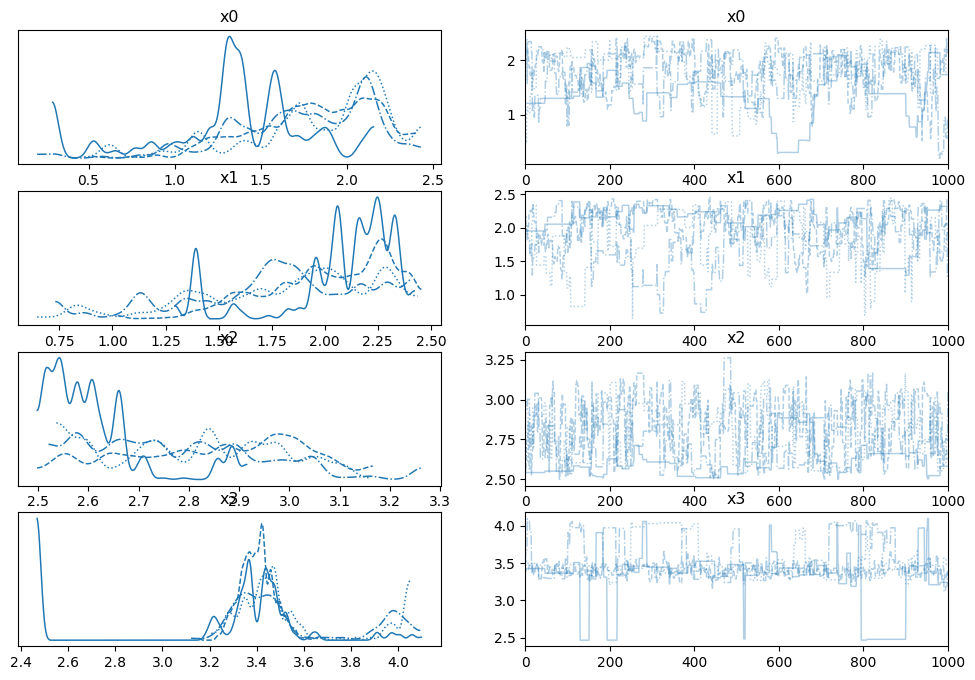

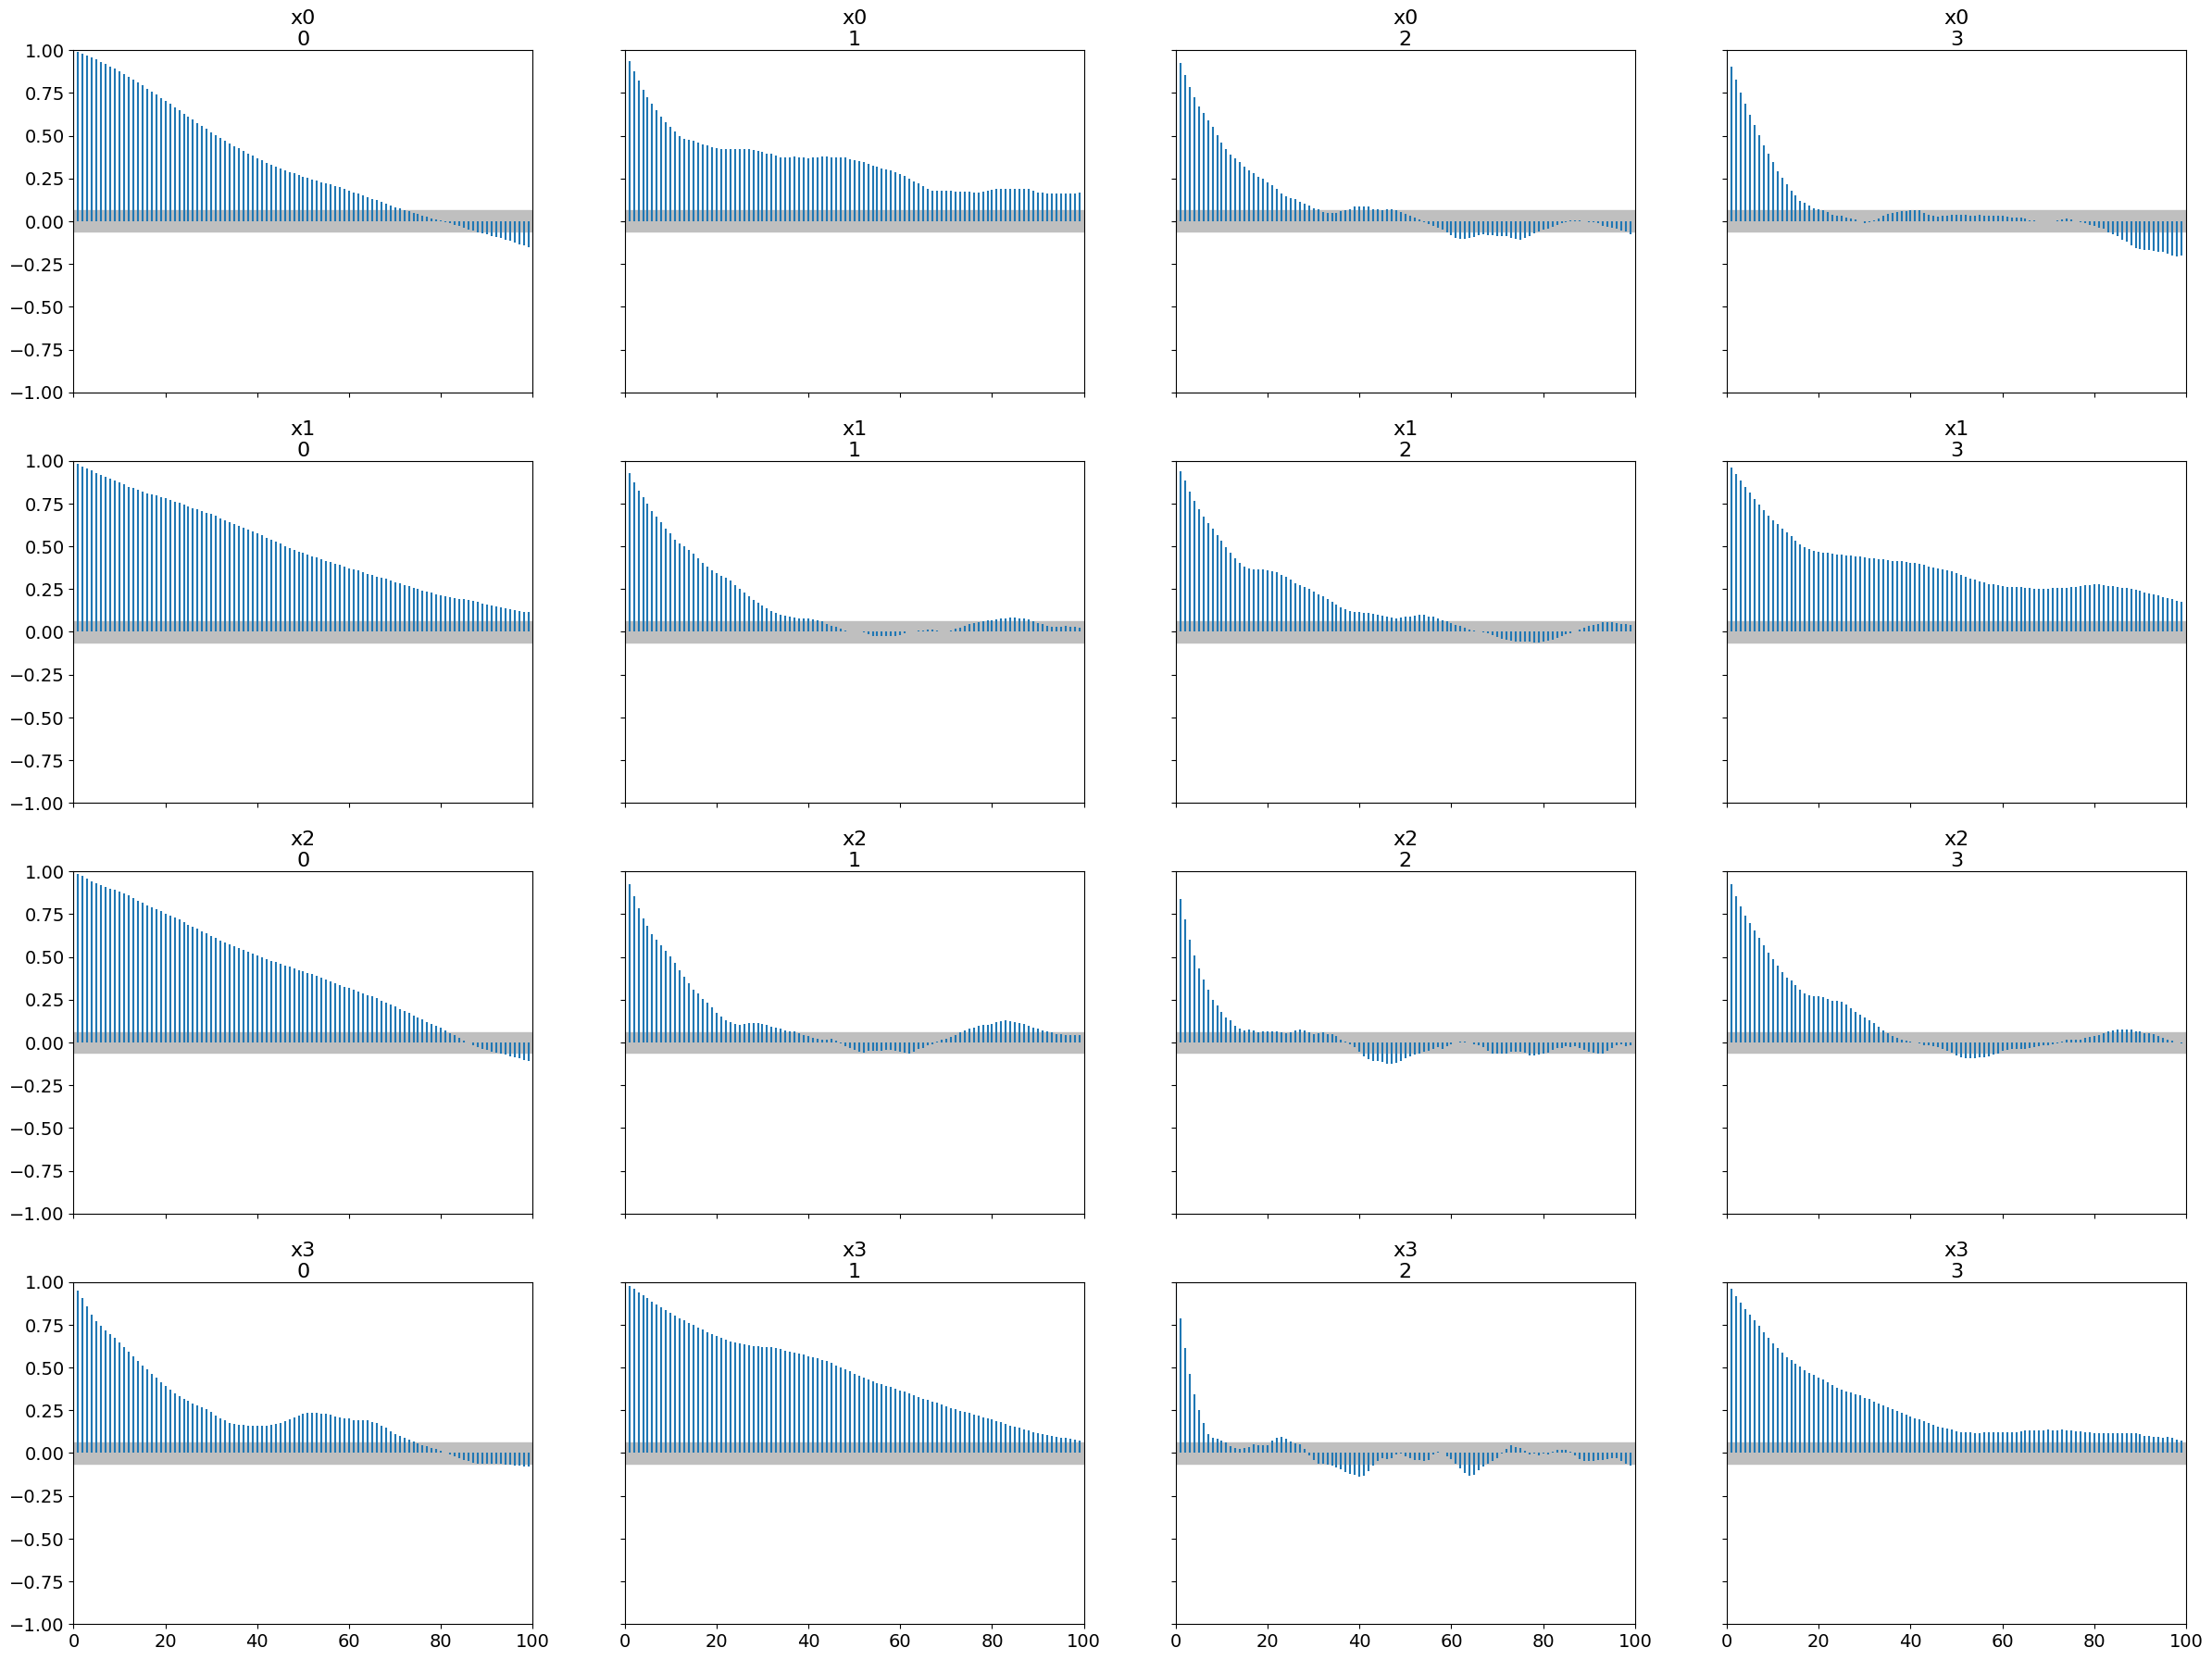

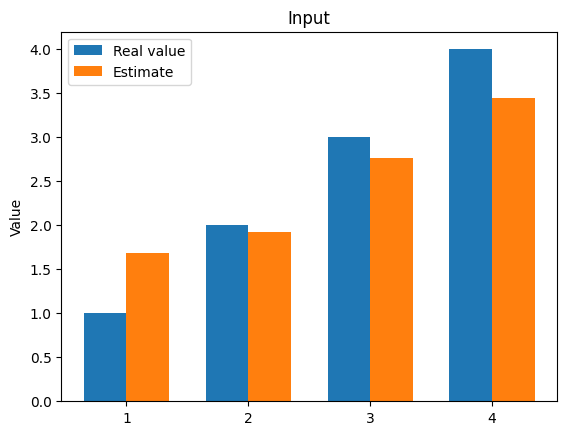

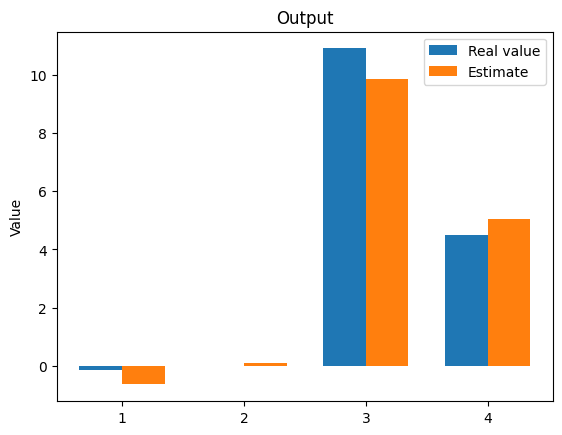

The function inverse took 766.9475445747375 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.03: 100%|██████████| 2000/2000 [01:28<00:00, 22.54it/s]


Sampling chain 2/4


Running chain, α = 0.01: 100%|██████████| 2000/2000 [01:28<00:00, 22.49it/s]


Sampling chain 3/4


Running chain, α = 0.17: 100%|██████████| 2000/2000 [01:28<00:00, 22.57it/s]


Sampling chain 4/4


Running chain, α = 0.09: 100%|██████████| 2000/2000 [01:28<00:00, 22.57it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.965 2.957 4.879 4.497]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.965  0.338   2.534    3.574      0.048    0.034      52.0      34.0   
x1  2.957  0.364   2.503    3.839      0.099    0.071      17.0      27.0   
x2  4.879  0.136   4.669    5.150      0.014    0.010     104.0     143.0   
x3  4.497  0.065   4.388    4.627      0.006    0.004     136.0     116.0   

    r_hat  
x0   1.07  
x1   1.17  
x2   1.08  
x3   1.03  
Autocorrelation...
the difference between estimated values [1.965 0.957 1.879 0.497]
 the difference between outputs of two models are [ 7.2782183  4.9093657 11.206668   6.274972 ]


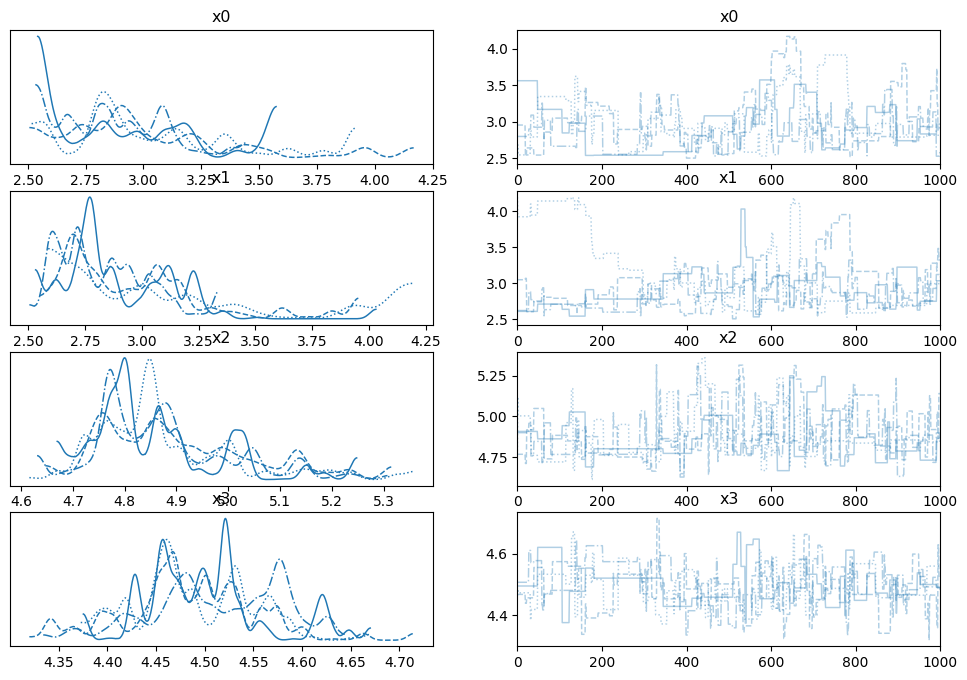

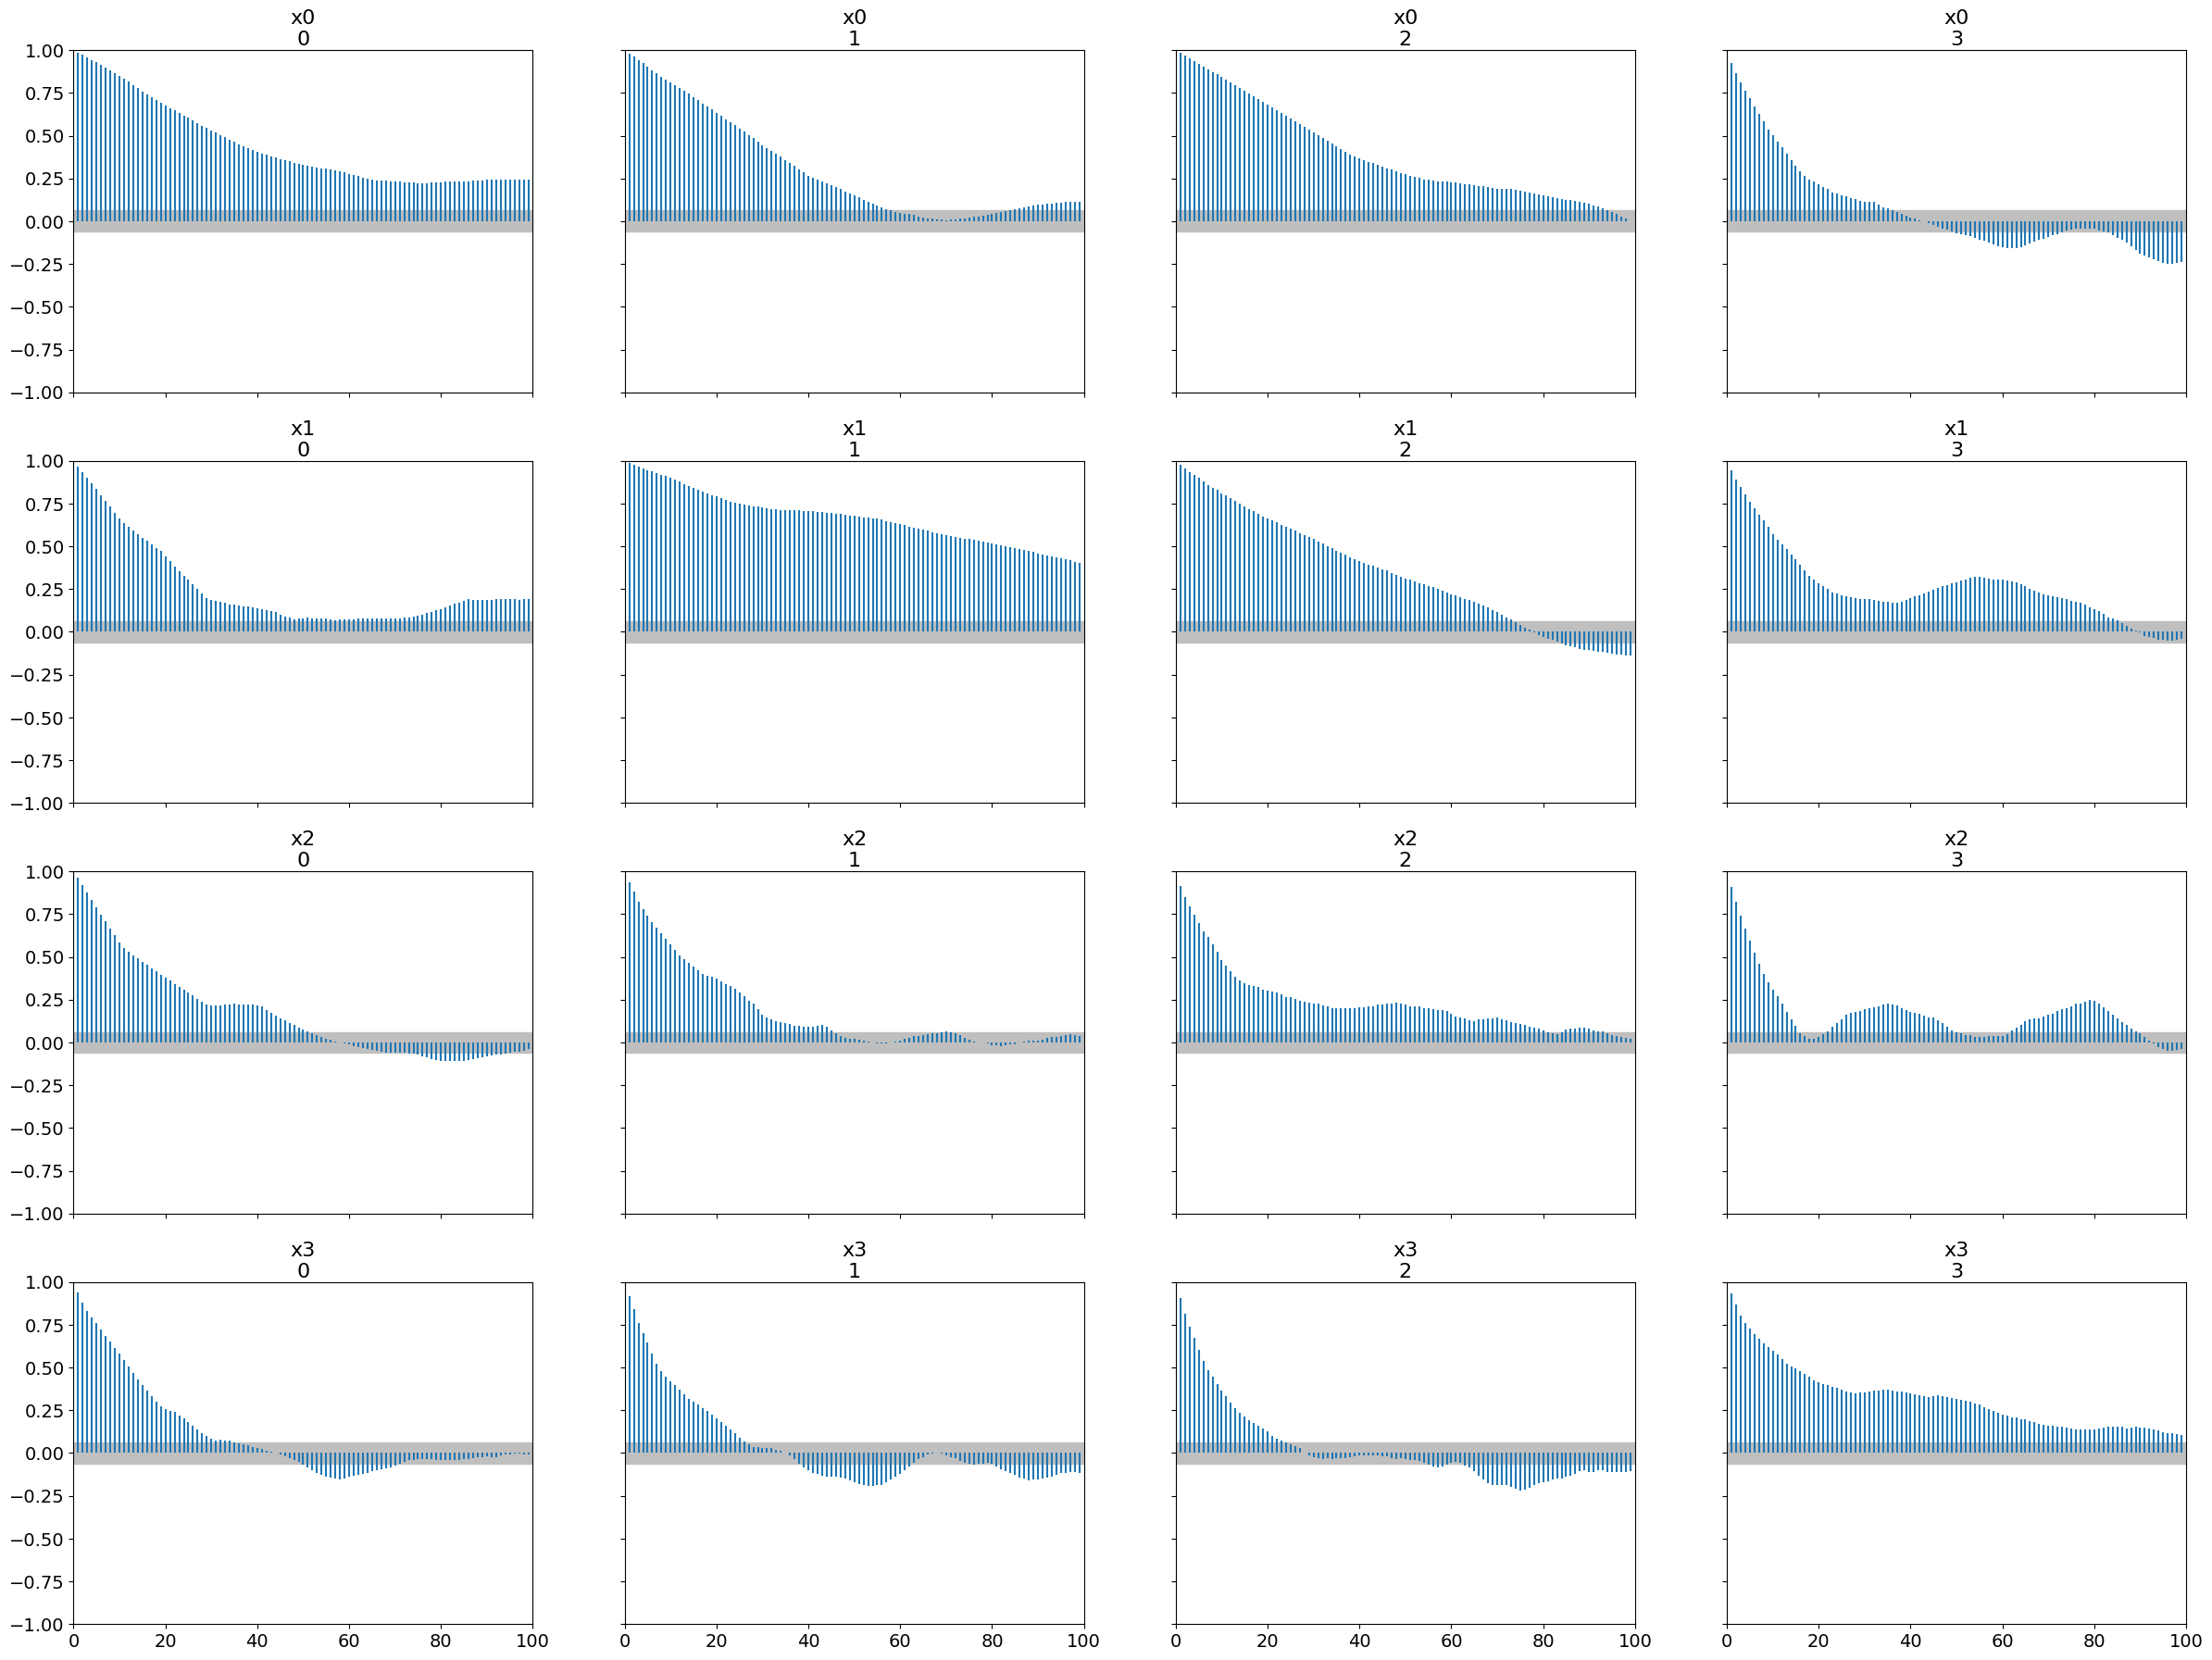

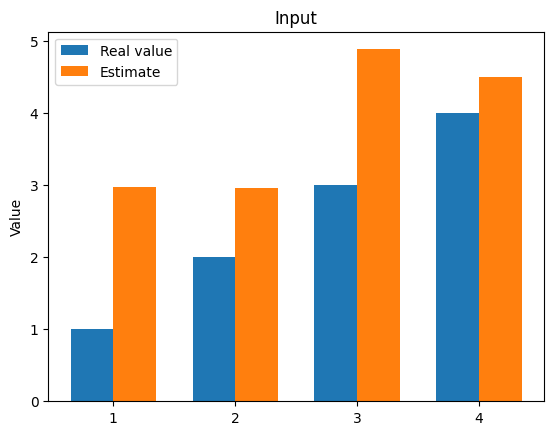

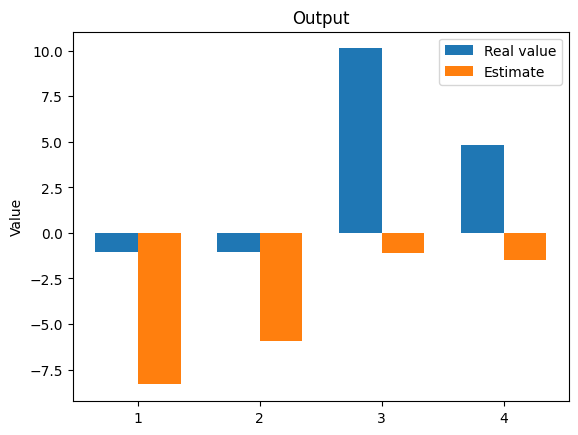

The function inverse took 374.2113416194916 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.39: 100%|██████████| 2000/2000 [01:29<00:00, 22.44it/s]


Sampling chain 2/4


Running chain, α = 0.36: 100%|██████████| 2000/2000 [01:28<00:00, 22.52it/s]


Sampling chain 3/4


Running chain, α = 0.11: 100%|██████████| 2000/2000 [01:29<00:00, 22.25it/s]


Sampling chain 4/4


Running chain, α = 0.18: 100%|██████████| 2000/2000 [01:33<00:00, 21.38it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.63  1.754 2.949 3.406]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.630  0.356   0.945    2.179      0.040    0.028      87.0     181.0   
x1  1.754  0.316   1.195    2.251      0.044    0.031      66.0     207.0   
x2  2.949  0.235   2.549    3.361      0.032    0.023      55.0     239.0   
x3  3.406  0.685   2.340    4.196      0.301    0.226       8.0     161.0   

    r_hat  
x0   1.05  
x1   1.07  
x2   1.07  
x3   1.51  
Autocorrelation...
the difference between estimated values [0.63  0.246 0.051 0.594]
 the difference between outputs of two models are [2.8338805e-01 3.6902022e-01 2.3784637e-03 4.3388615e+00]


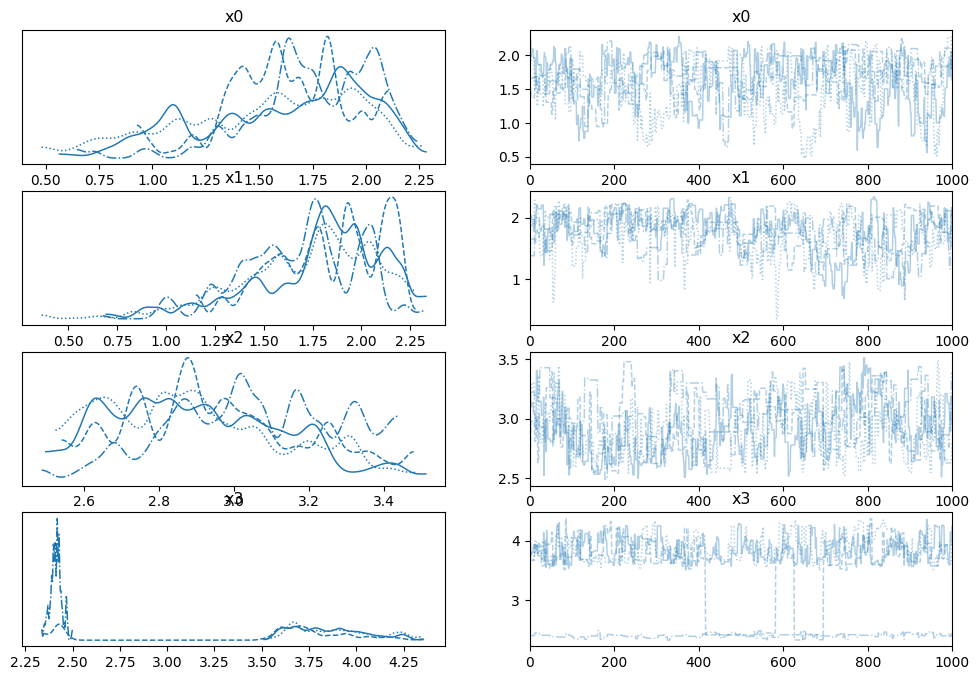

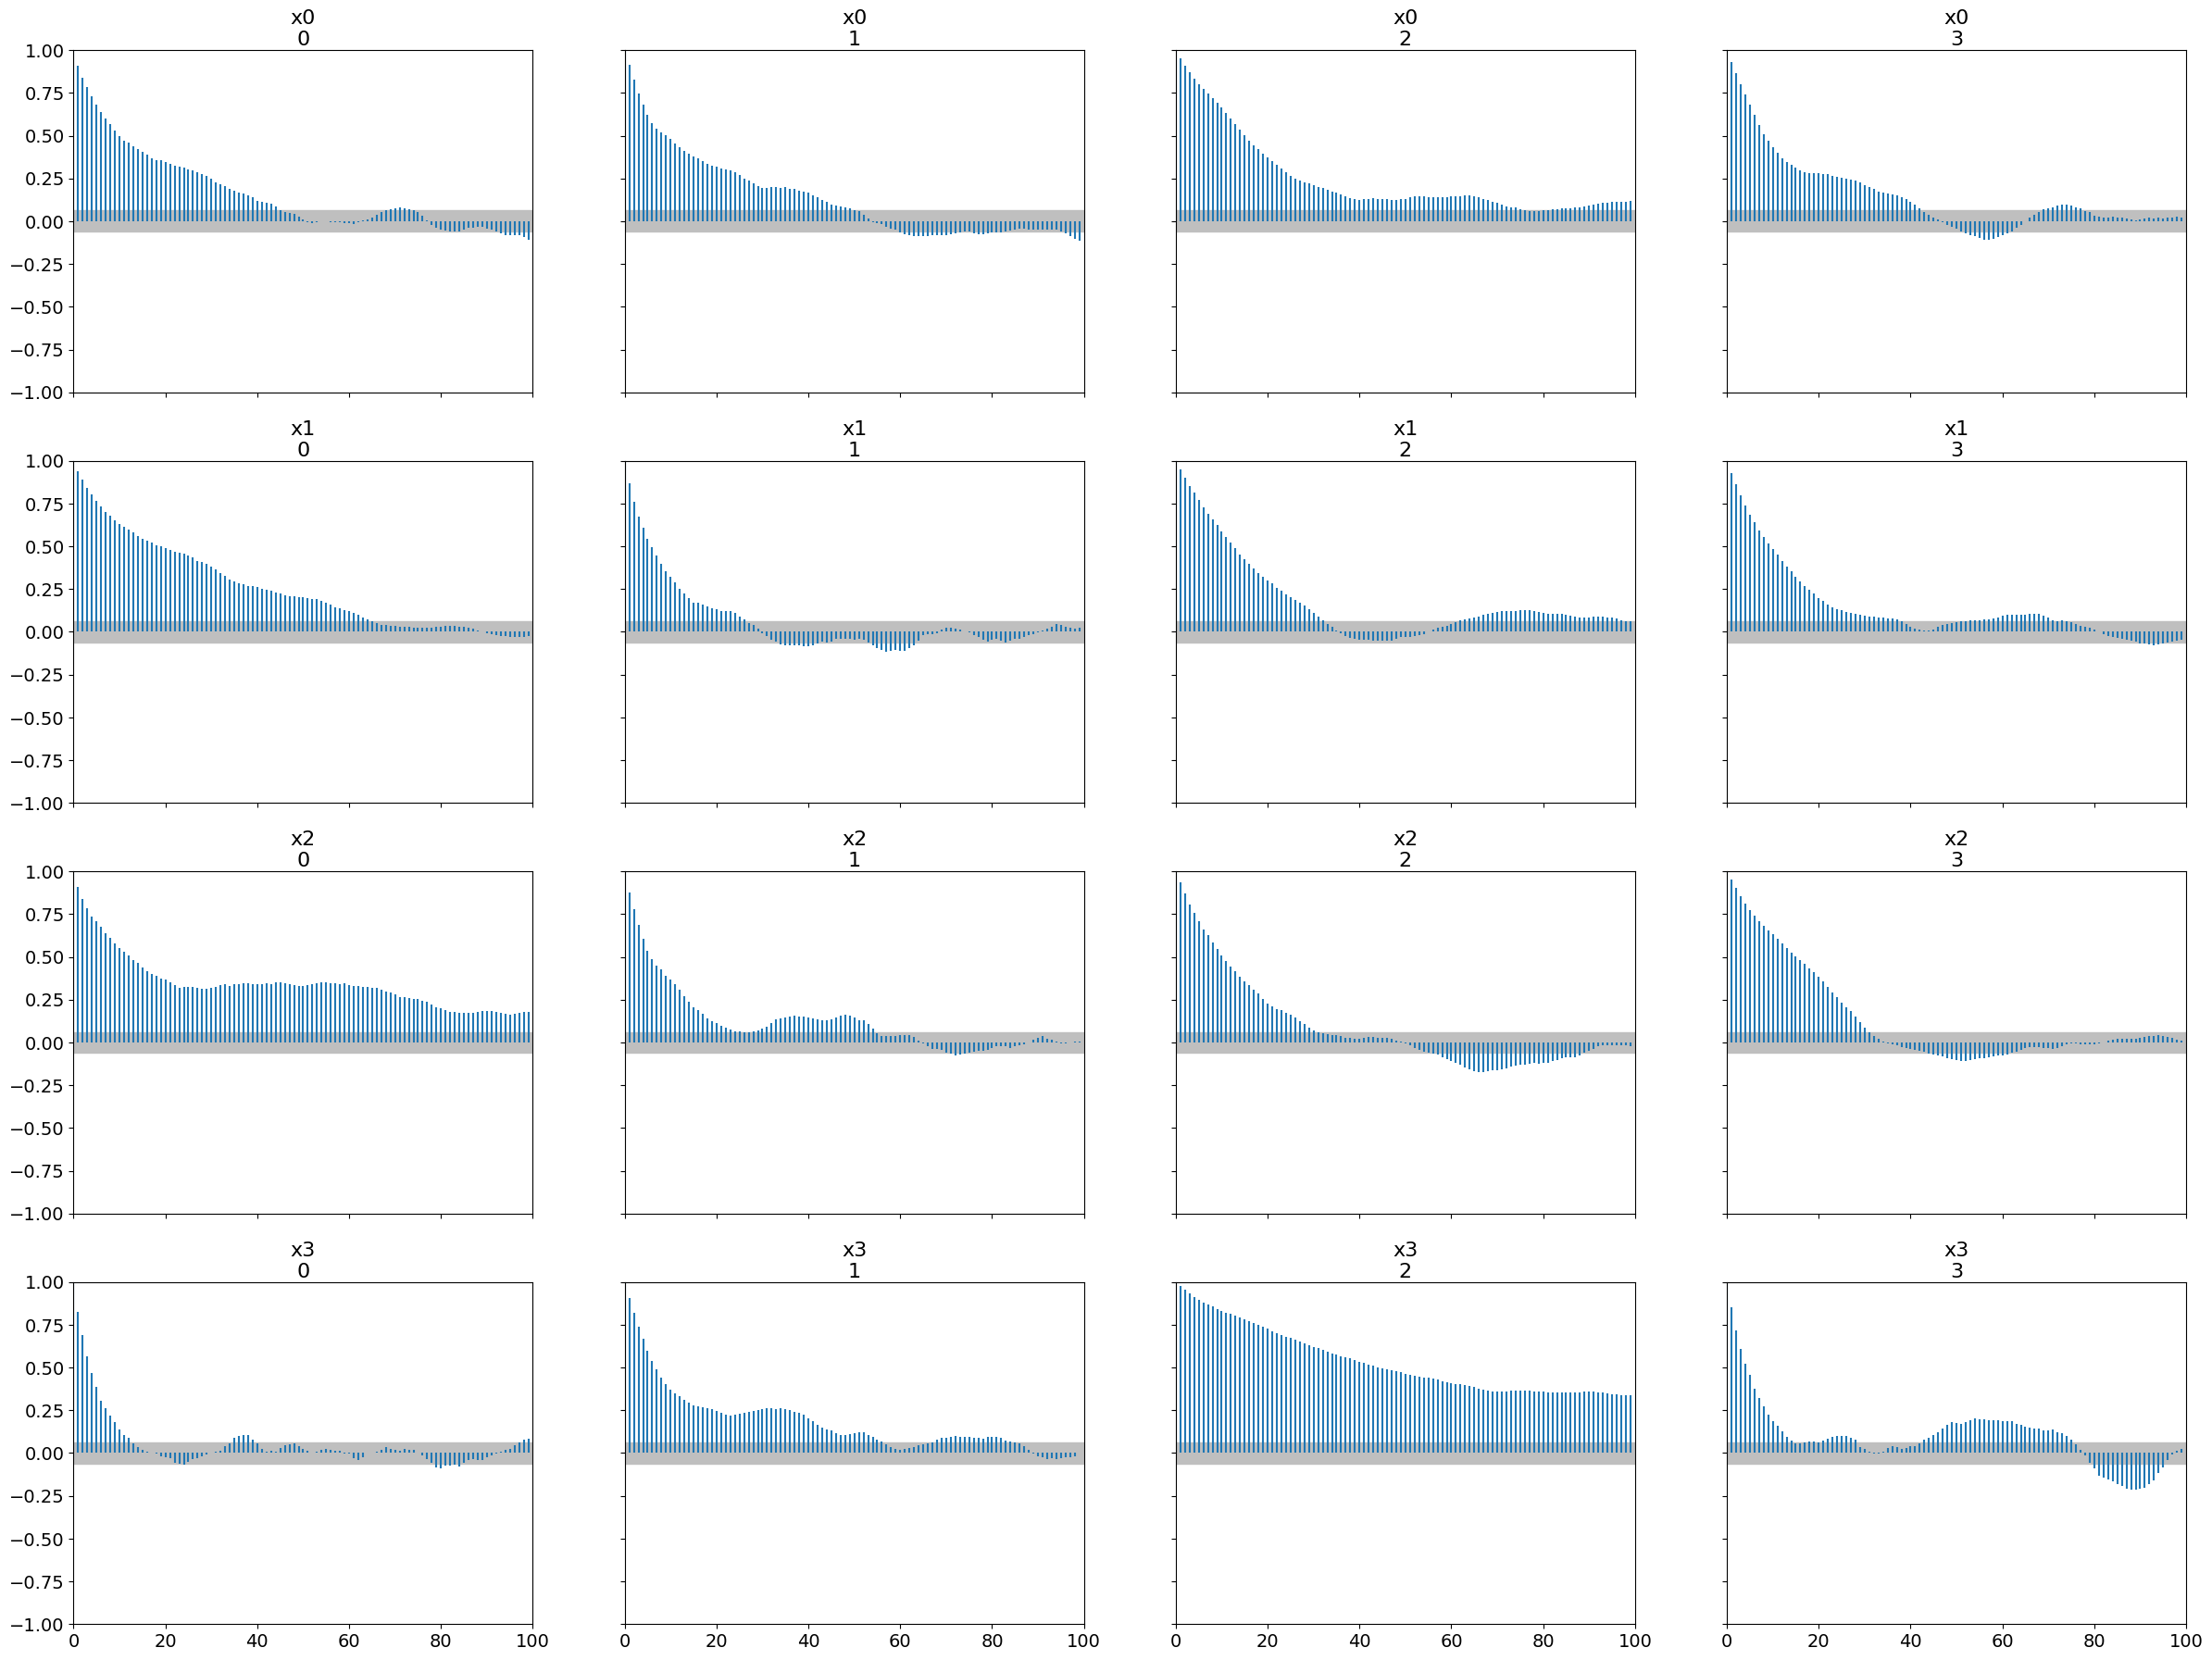

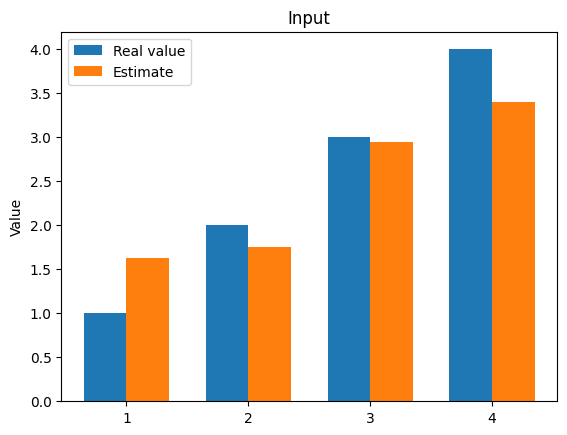

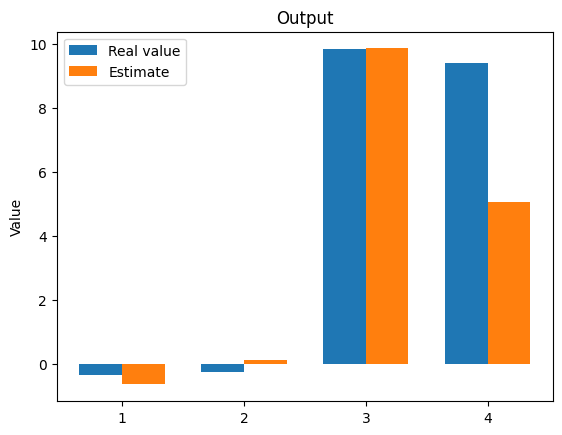

The function inverse took 375.6099154949188 seconds.


In [17]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="AM")
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=0.1, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")

real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.04: 100%|██████████| 2000/2000 [02:53<00:00, 11.52it/s]


Sampling chain 2/4


Running chain, α = 0.10: 100%|██████████| 2000/2000 [03:12<00:00, 10.41it/s]


Sampling chain 3/4


Running chain, α = 0.10: 100%|██████████| 2000/2000 [03:02<00:00, 10.97it/s]


Sampling chain 4/4


Running chain, α = 0.00: 100%|██████████| 2000/2000 [03:00<00:00, 11.07it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.957 1.981 2.945 2.472]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.957  0.349   1.347    2.460      0.133    0.099       9.0      39.0   
x1  1.981  0.330   1.436    2.441      0.132    0.098       7.0      12.0   
x2  2.945  0.216   2.521    3.180      0.066    0.048      13.0      17.0   
x3  2.472  0.016   2.460    2.489      0.001    0.001     194.0     157.0   

    r_hat  
x0   1.42  
x1   1.57  
x2   1.23  
x3   1.05  
Autocorrelation...
the difference between estimated values [0.957 0.019 0.055 1.528]
 the difference between outputs of two models are [0.68929386 0.03002322 0.40847492 1.02358103]


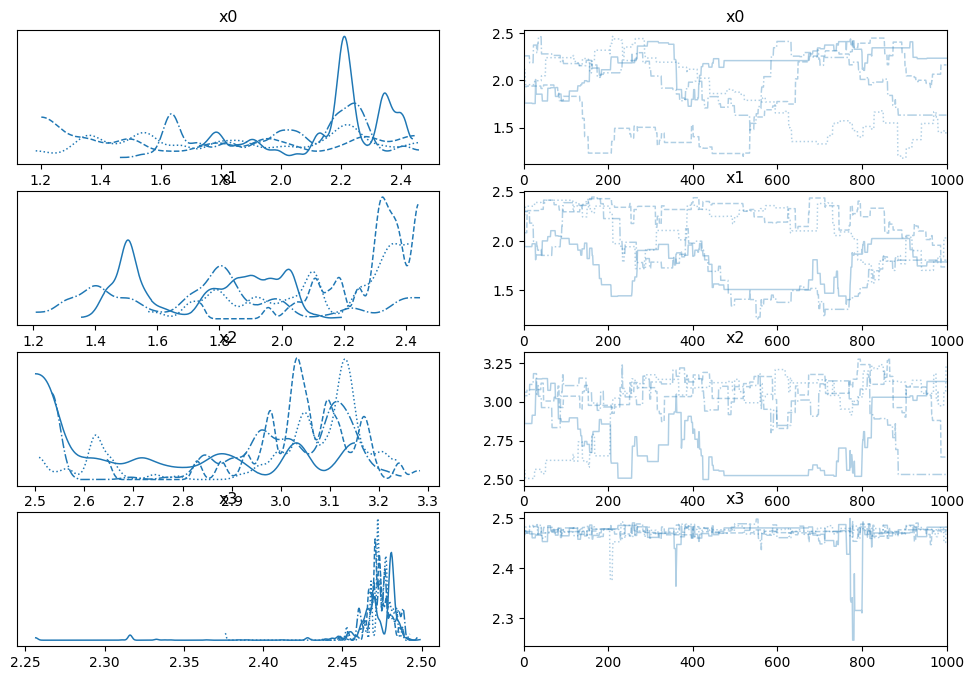

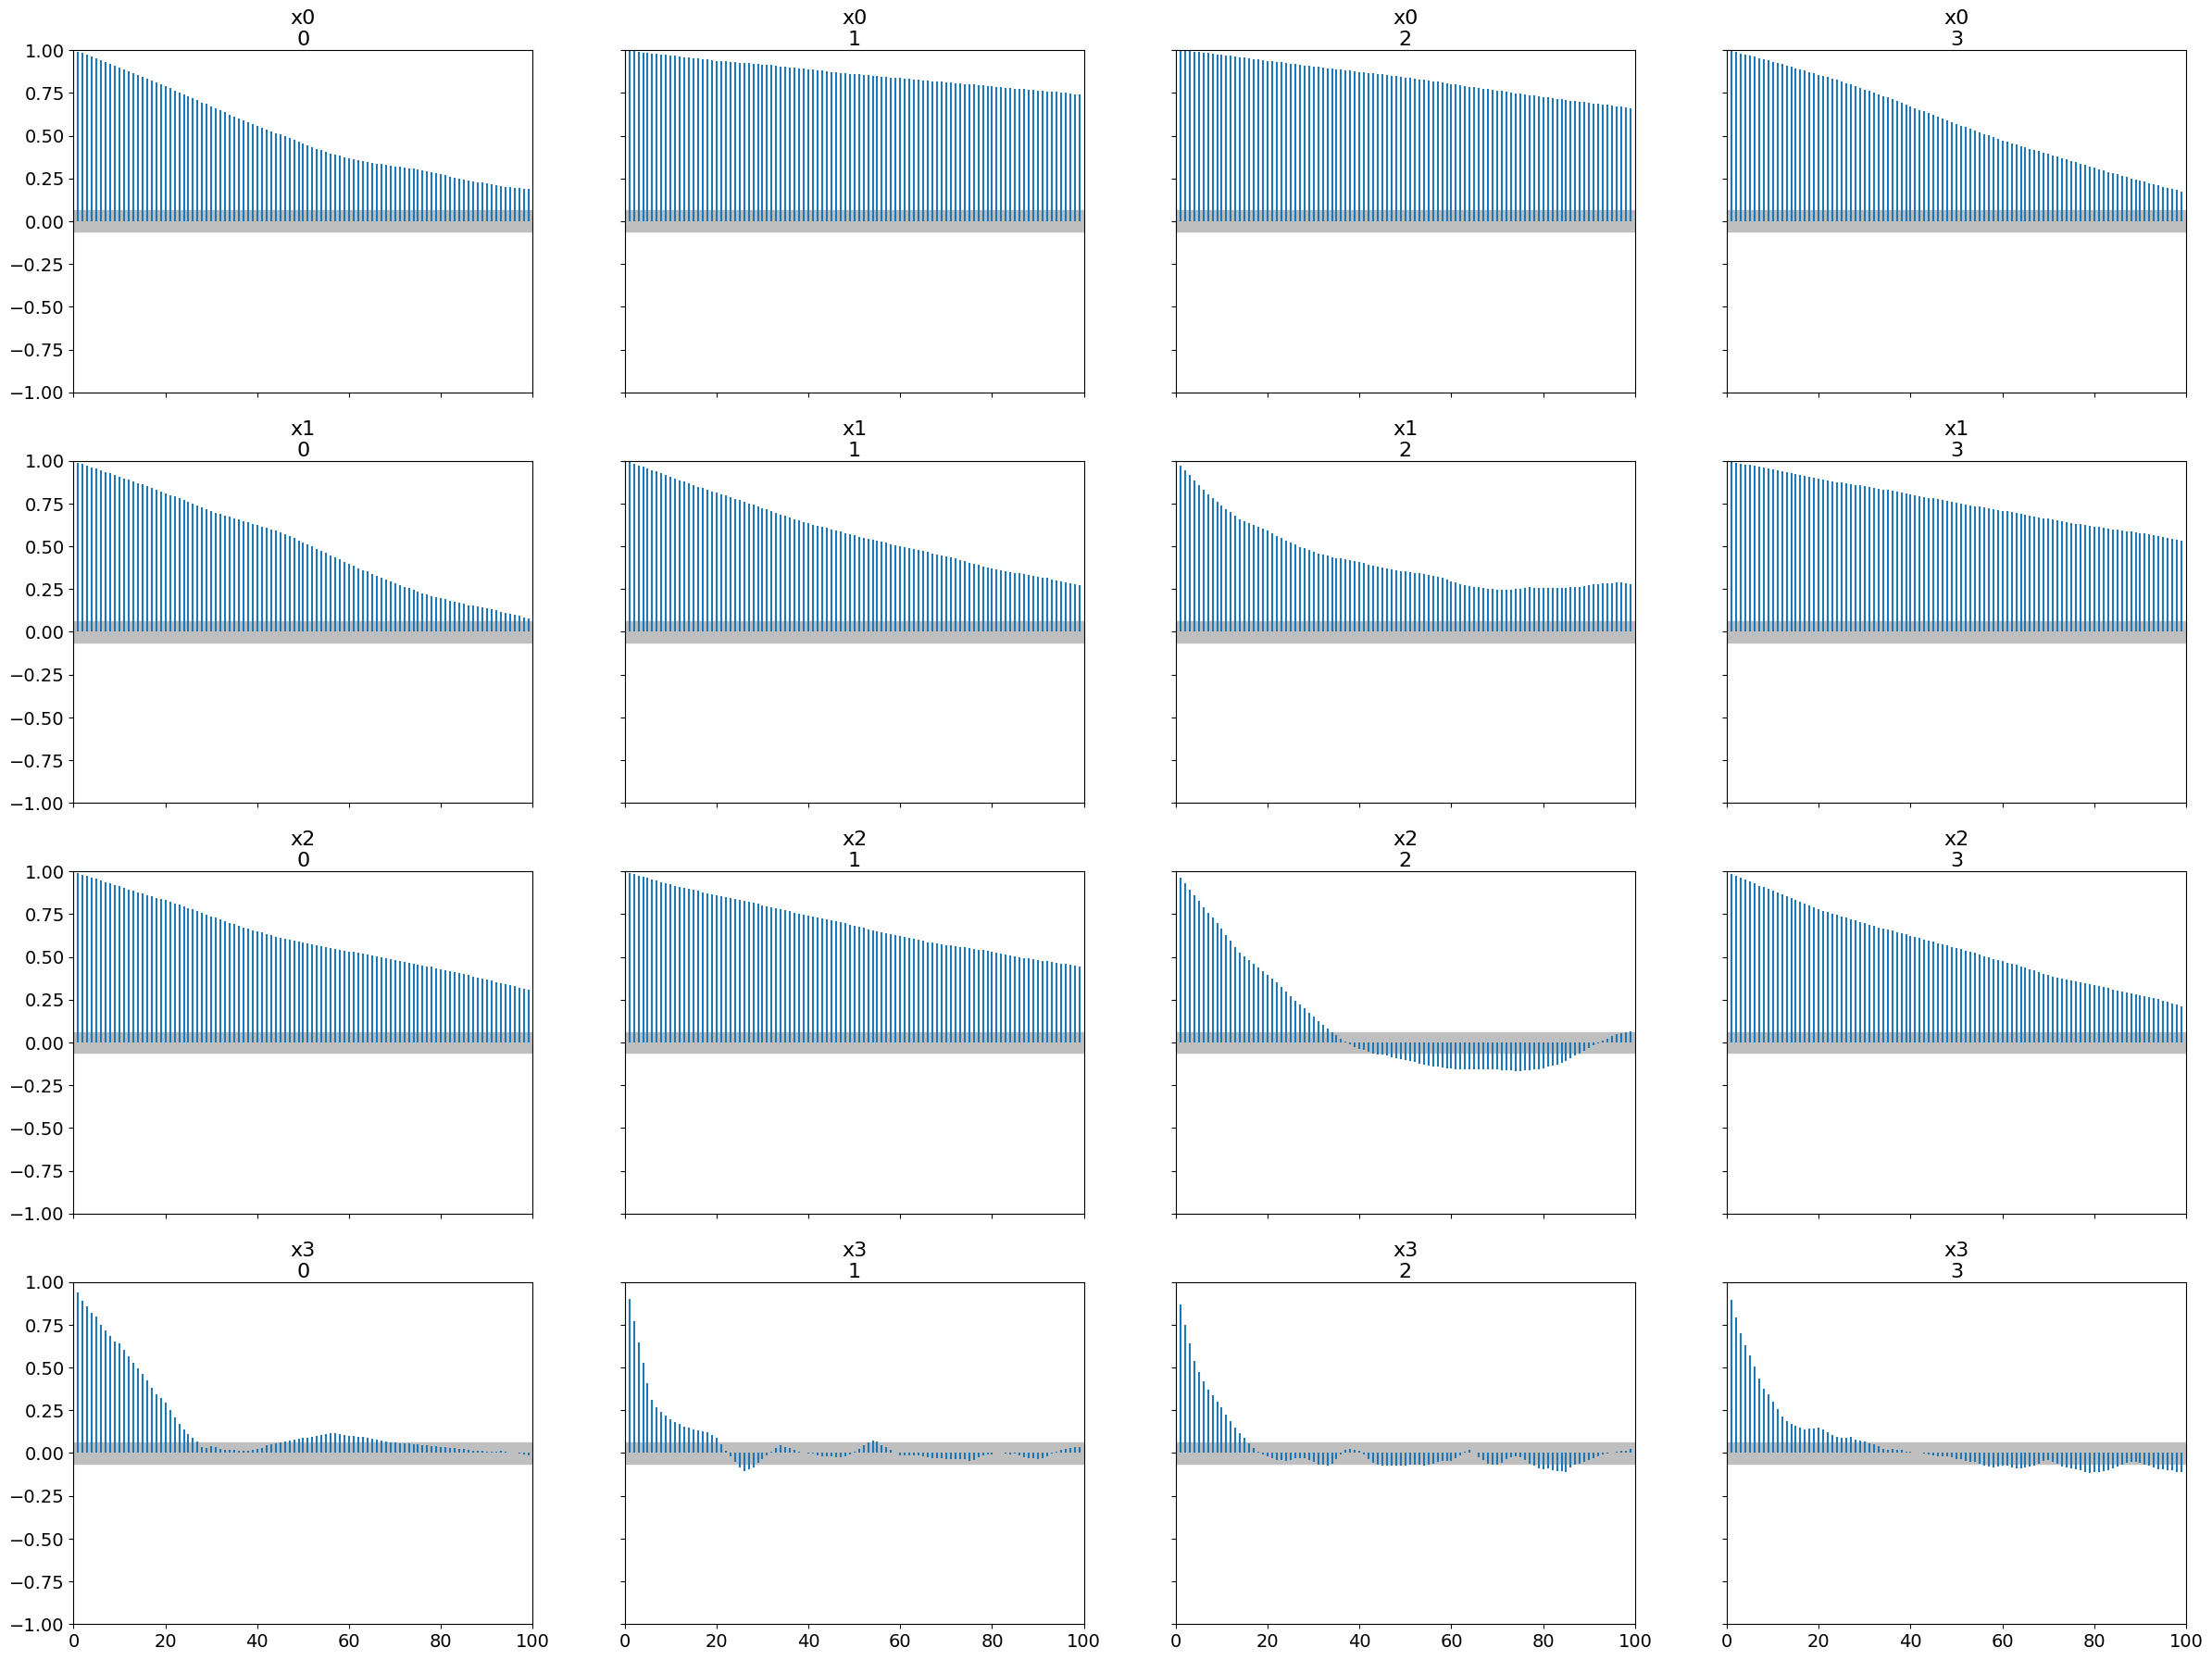

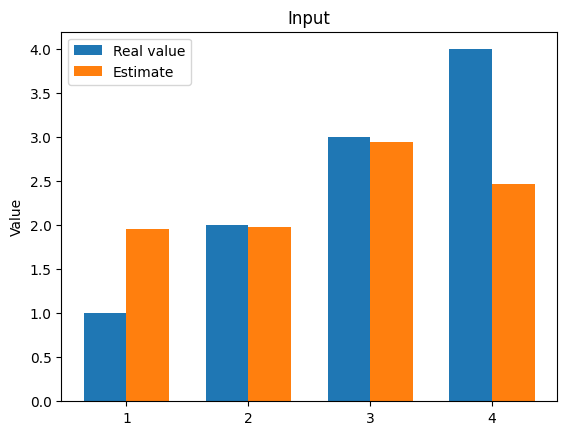

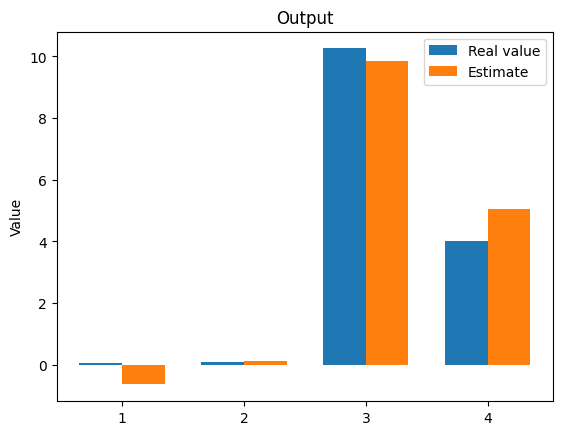

The function inverse took 732.5357847213745 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.49: 100%|██████████| 2000/2000 [01:33<00:00, 21.39it/s]


Sampling chain 2/4


Running chain, α = 0.39: 100%|██████████| 2000/2000 [01:29<00:00, 22.27it/s]


Sampling chain 3/4


Running chain, α = 0.59: 100%|██████████| 2000/2000 [01:28<00:00, 22.67it/s]


Sampling chain 4/4


Running chain, α = 0.50: 100%|██████████| 2000/2000 [01:27<00:00, 22.92it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.873 2.969 2.855 2.857]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.873  0.208   2.535    3.232      0.037    0.027      35.0     114.0   
x1  2.969  0.345   2.511    3.524      0.064    0.047      66.0      28.0   
x2  2.855  0.101   2.647    3.034      0.005    0.004     370.0     547.0   
x3  2.857  0.123   2.625    3.086      0.008    0.005     254.0     654.0   

    r_hat  
x0   1.09  
x1   1.06  
x2   1.02  
x3   1.01  
Autocorrelation...
the difference between estimated values [1.873 0.969 0.145 1.143]
 the difference between outputs of two models are [7.3249664  4.8988614  0.08246225 0.4749769 ]


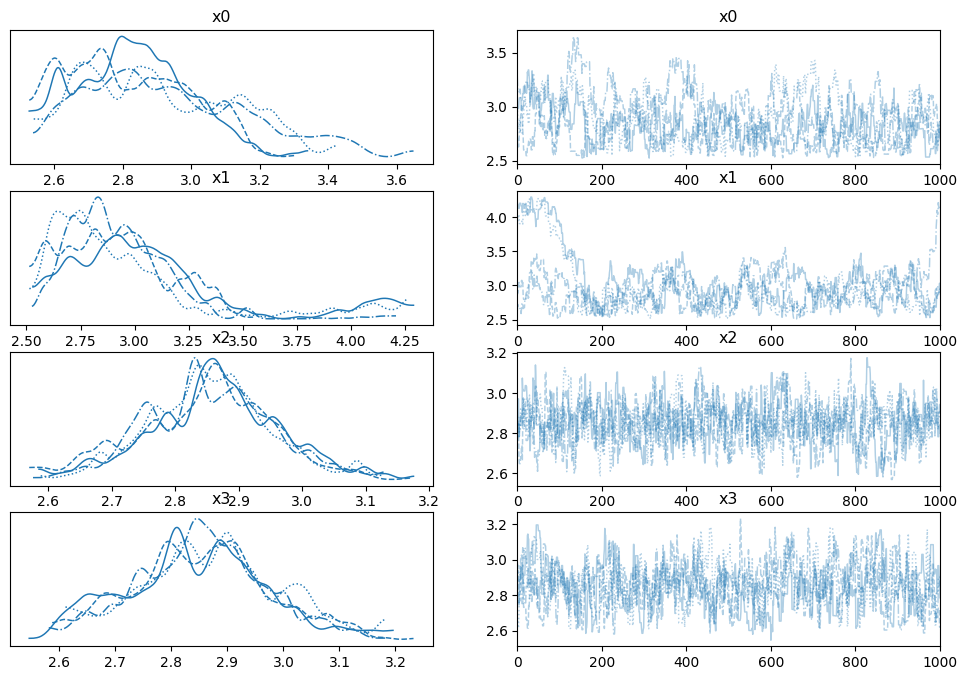

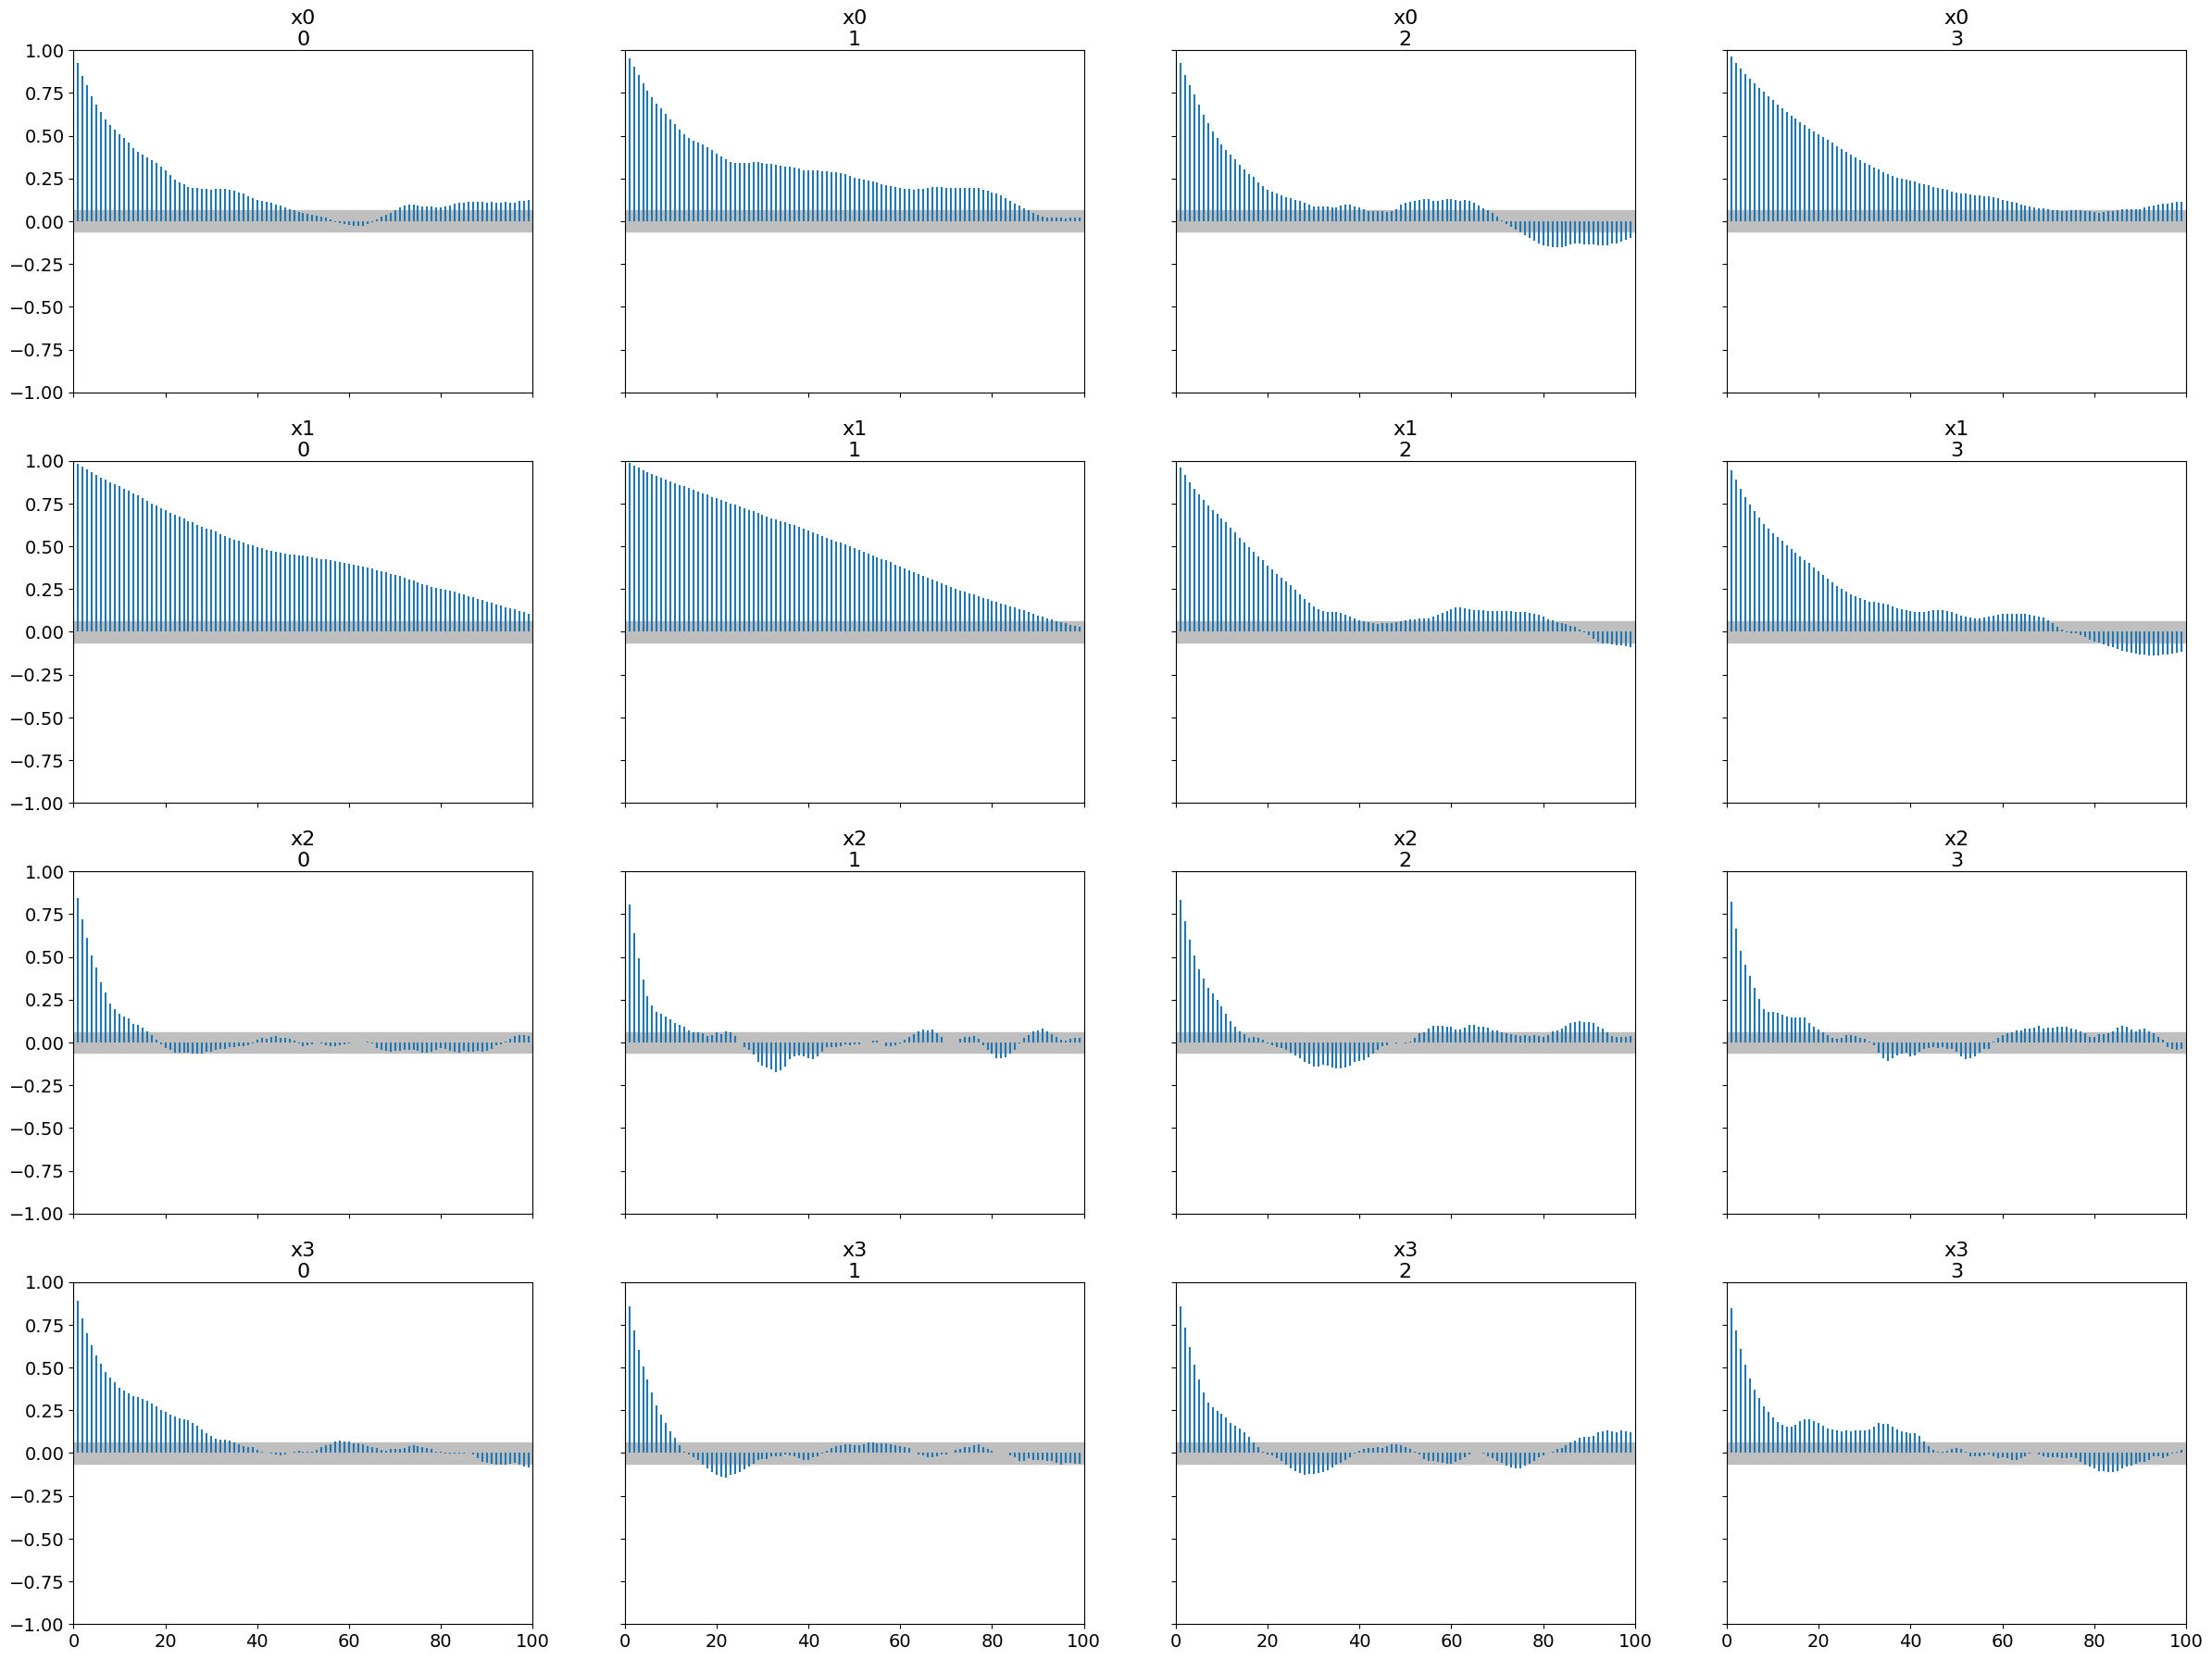

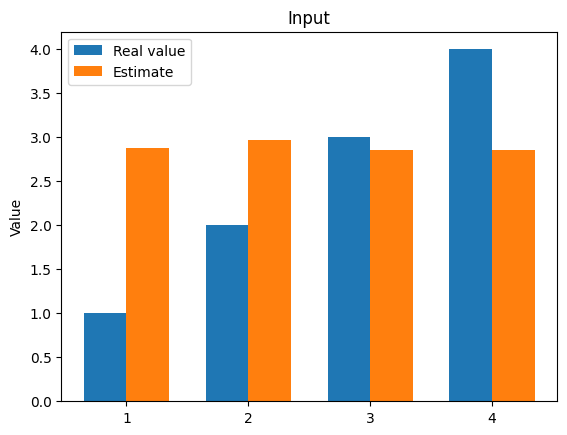

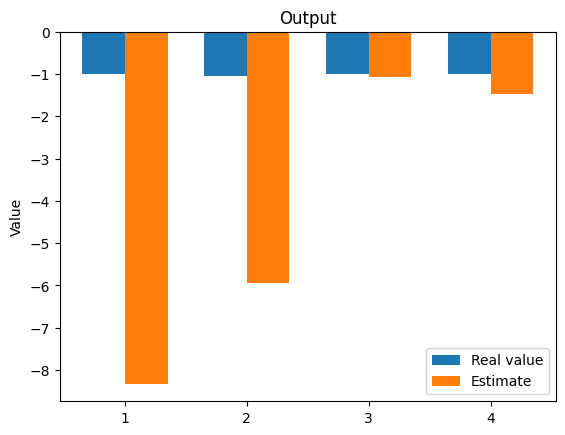

The function inverse took 375.6751160621643 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/4


Running chain, α = 0.27: 100%|██████████| 2000/2000 [01:27<00:00, 22.85it/s]


Sampling chain 2/4


Running chain, α = 0.26: 100%|██████████| 2000/2000 [01:27<00:00, 22.95it/s]


Sampling chain 3/4


Running chain, α = 0.38: 100%|██████████| 2000/2000 [01:26<00:00, 23.00it/s]


Sampling chain 4/4


Running chain, α = 0.42: 100%|██████████| 2000/2000 [01:27<00:00, 22.92it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.614 1.637 2.919 2.363]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.614  0.386   0.827    2.212      0.151    0.112       8.0      13.0   
x1  1.637  0.473   0.716    2.239      0.184    0.136       8.0      14.0   
x2  2.919  0.293   2.508    3.433      0.047    0.034      55.0     171.0   
x3  2.363  0.039   2.289    2.431      0.002    0.001     615.0     792.0   

    r_hat  
x0   1.48  
x1   1.41  
x2   1.11  
x3   1.00  
Autocorrelation...
the difference between estimated values [0.614 0.363 0.081 1.637]
 the difference between outputs of two models are [0.2724034  0.46617365 0.00465584 1.2159557 ]


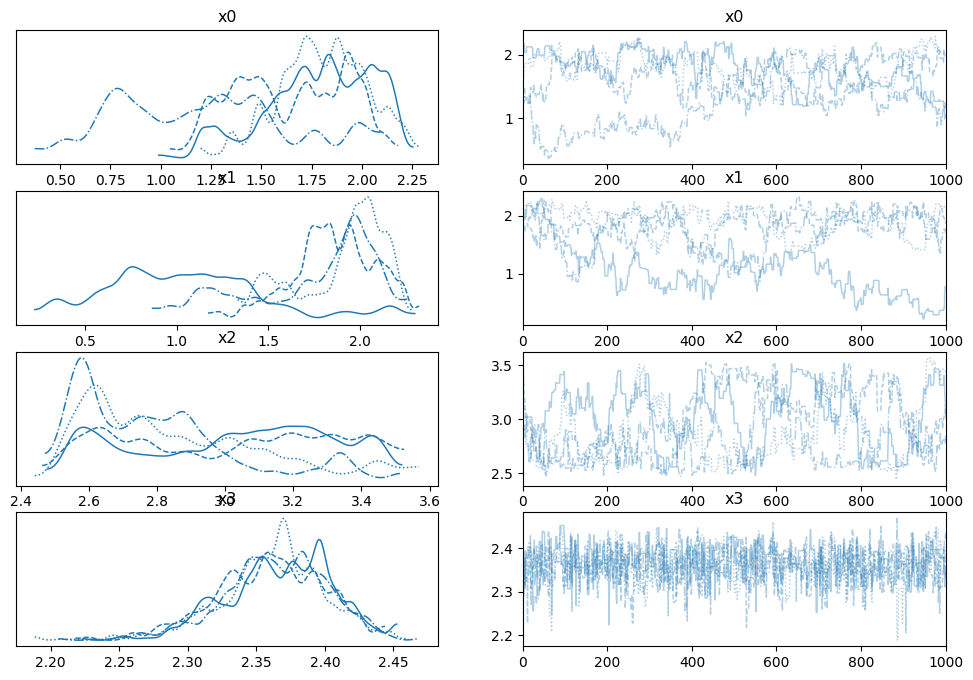

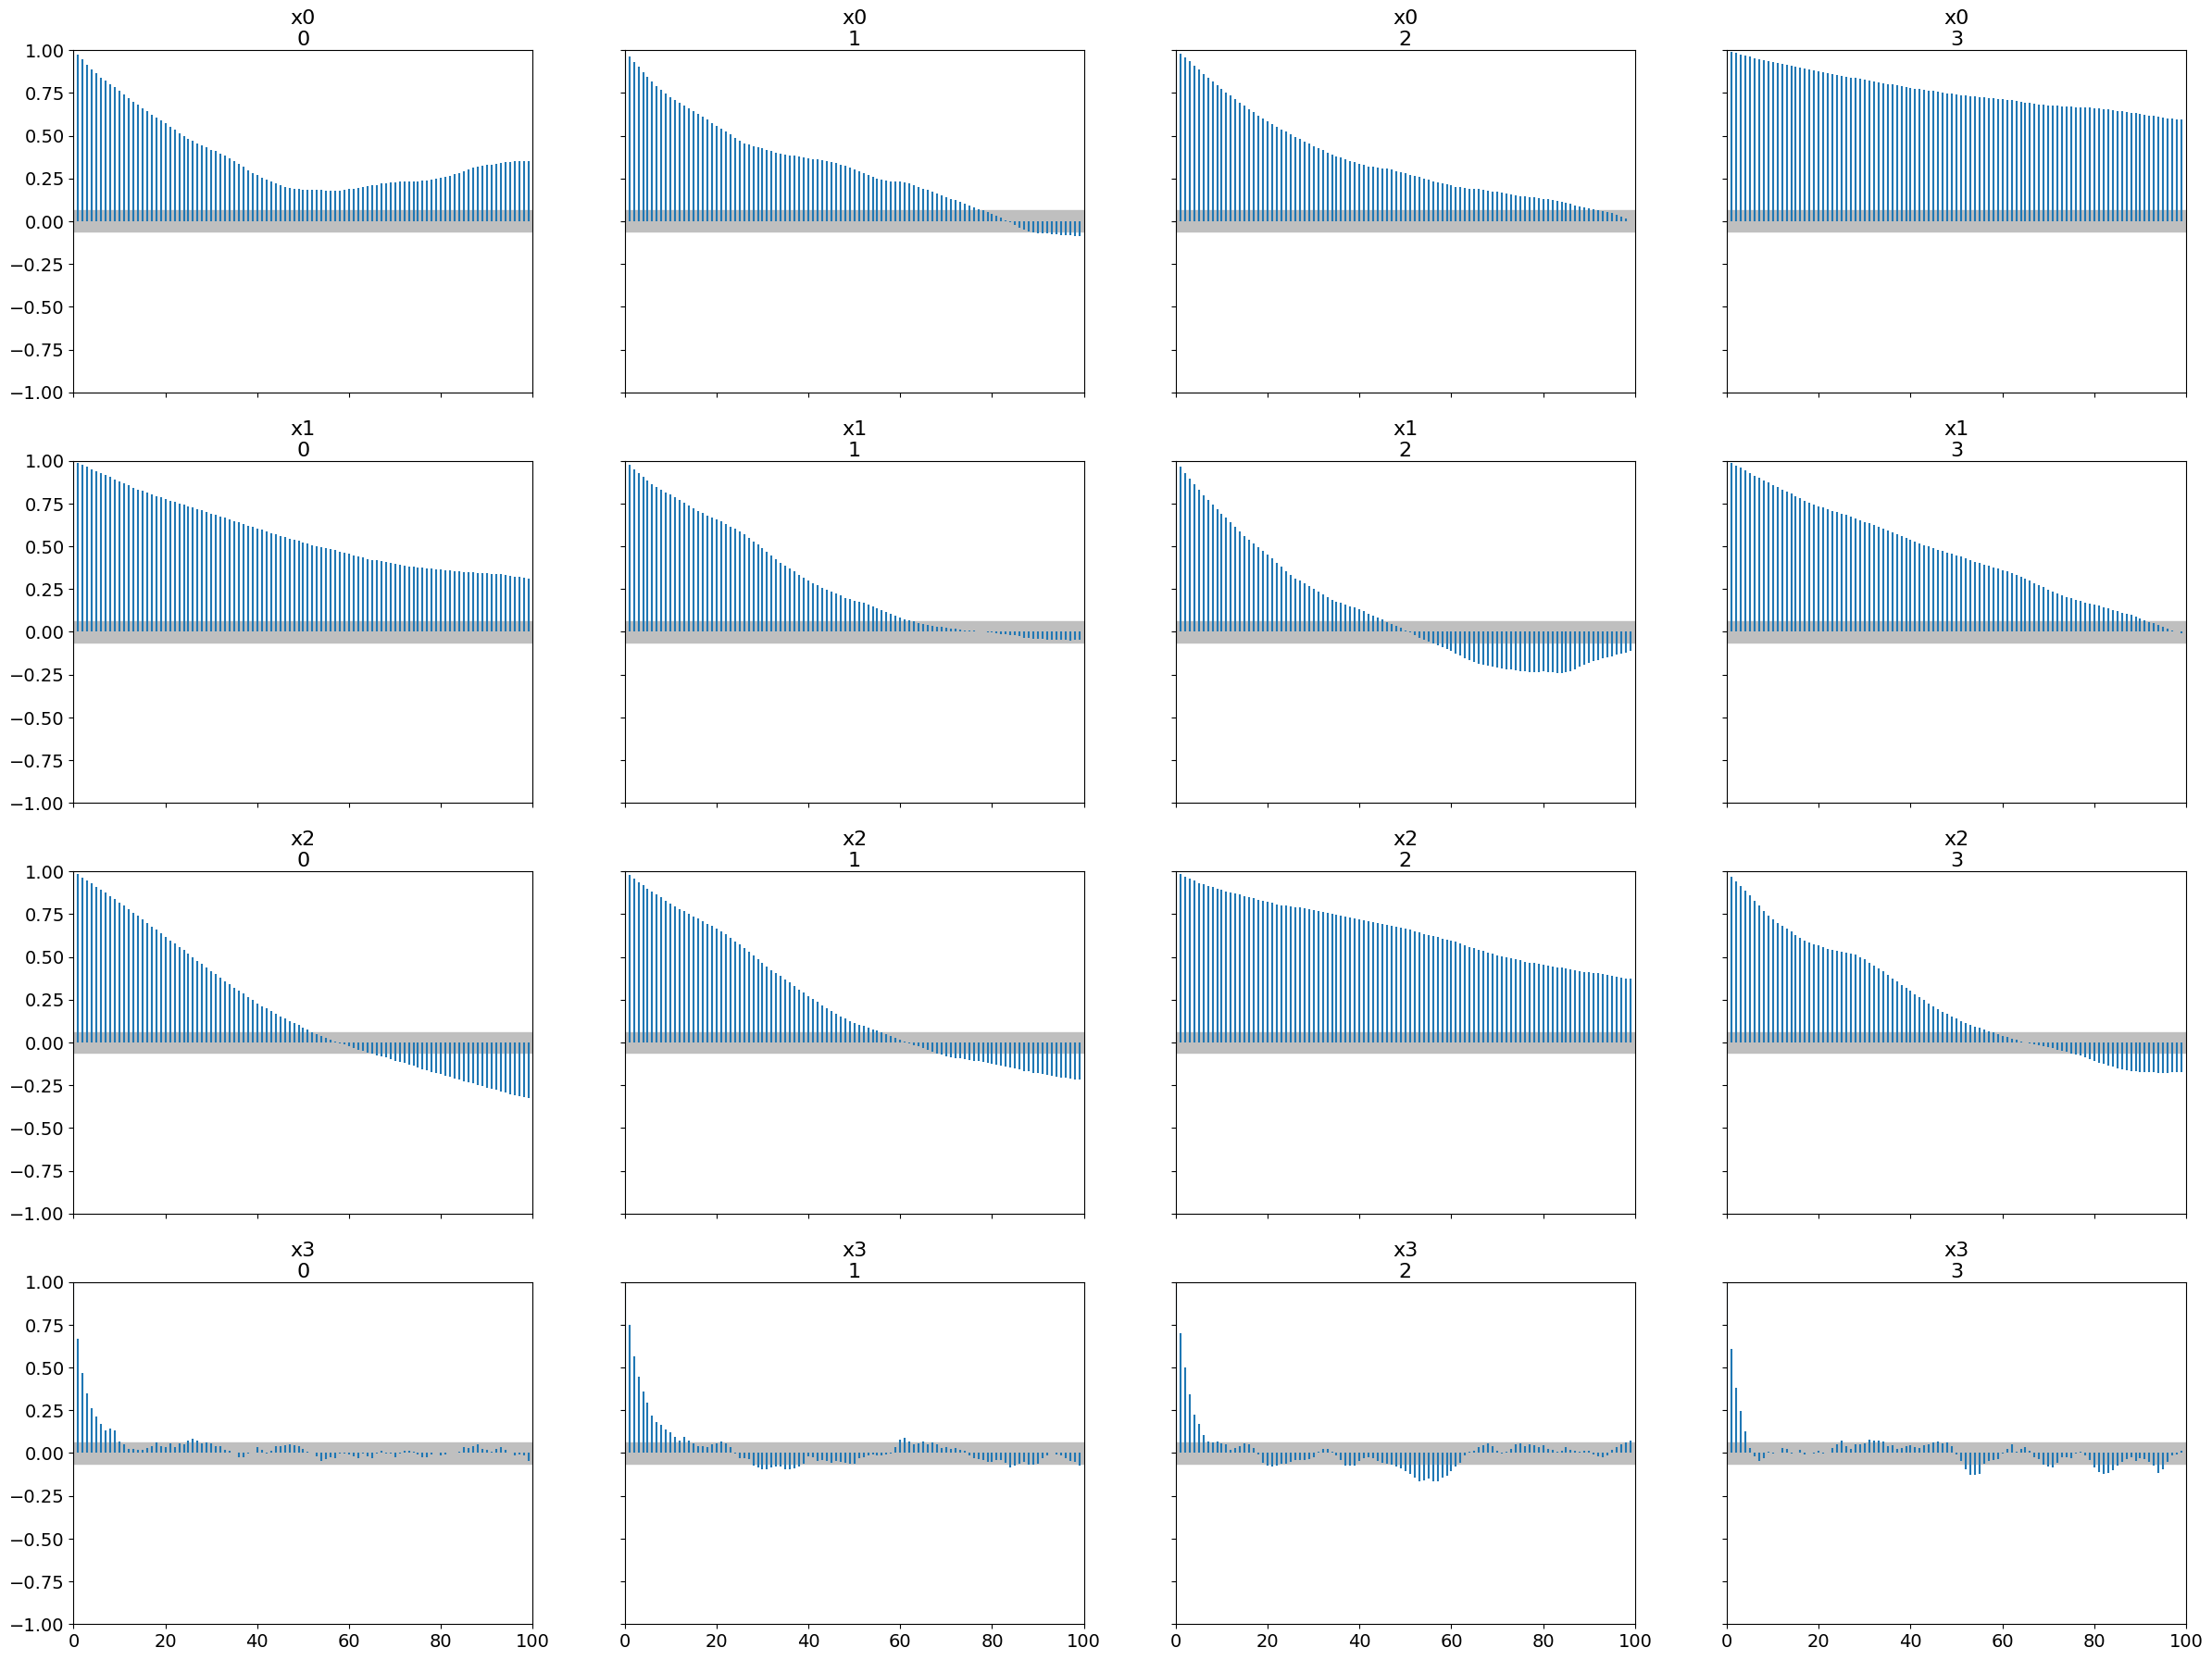

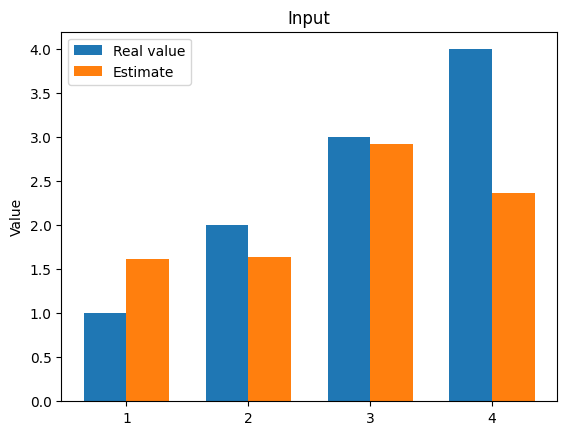

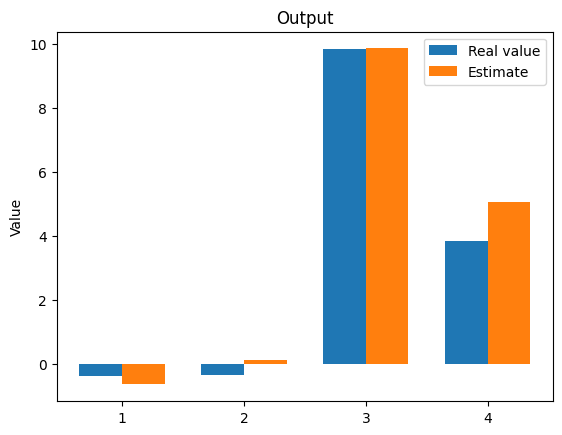

The function inverse took 358.823059797287 seconds.


In [19]:
estimate_MF2=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="MH")
estimate_LF2=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="MH")
estimate_HF2=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="MH")

real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.25: 100%|██████████| 4000/4000 [05:31<00:00, 12.08it/s]


Sampling chain 2/8


Running chain, α = 0.37: 100%|██████████| 4000/4000 [05:31<00:00, 12.08it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.21: 100%|██████████| 4000/4000 [05:31<00:00, 12.07it/s]


Sampling chain 8/8


Running chain, α = 0.28: 100%|██████████| 4000/4000 [05:31<00:00, 12.08it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.447 1.819 2.799 3.368]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.447  0.409   0.772    2.189      0.015    0.010     774.0    1161.0   
x1  1.819  0.343   1.244    2.411      0.013    0.009     750.0     600.0   
x2  2.799  0.169   2.526    3.030      0.006    0.005     702.0     668.0   
x3  3.368  0.256   3.268    4.058      0.034    0.024      89.0      46.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.07  
Autocorrelation...
the difference between estimated values [0.447 0.181 0.201 0.632]
 the difference between outputs of two models are [0.43621564 0.19550598 0.99418545 0.40142393]


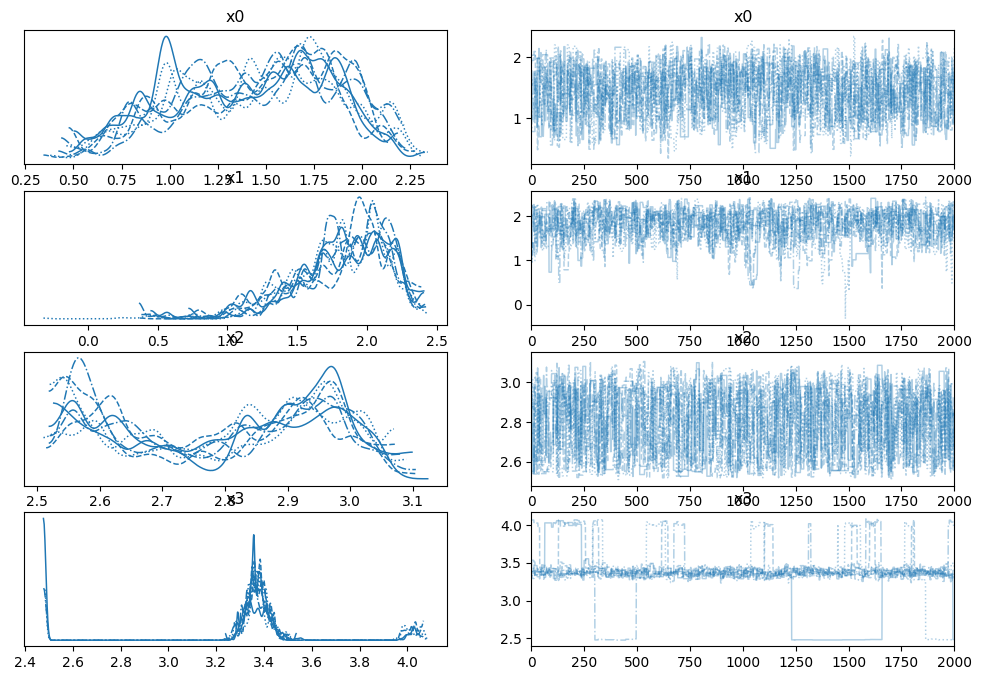

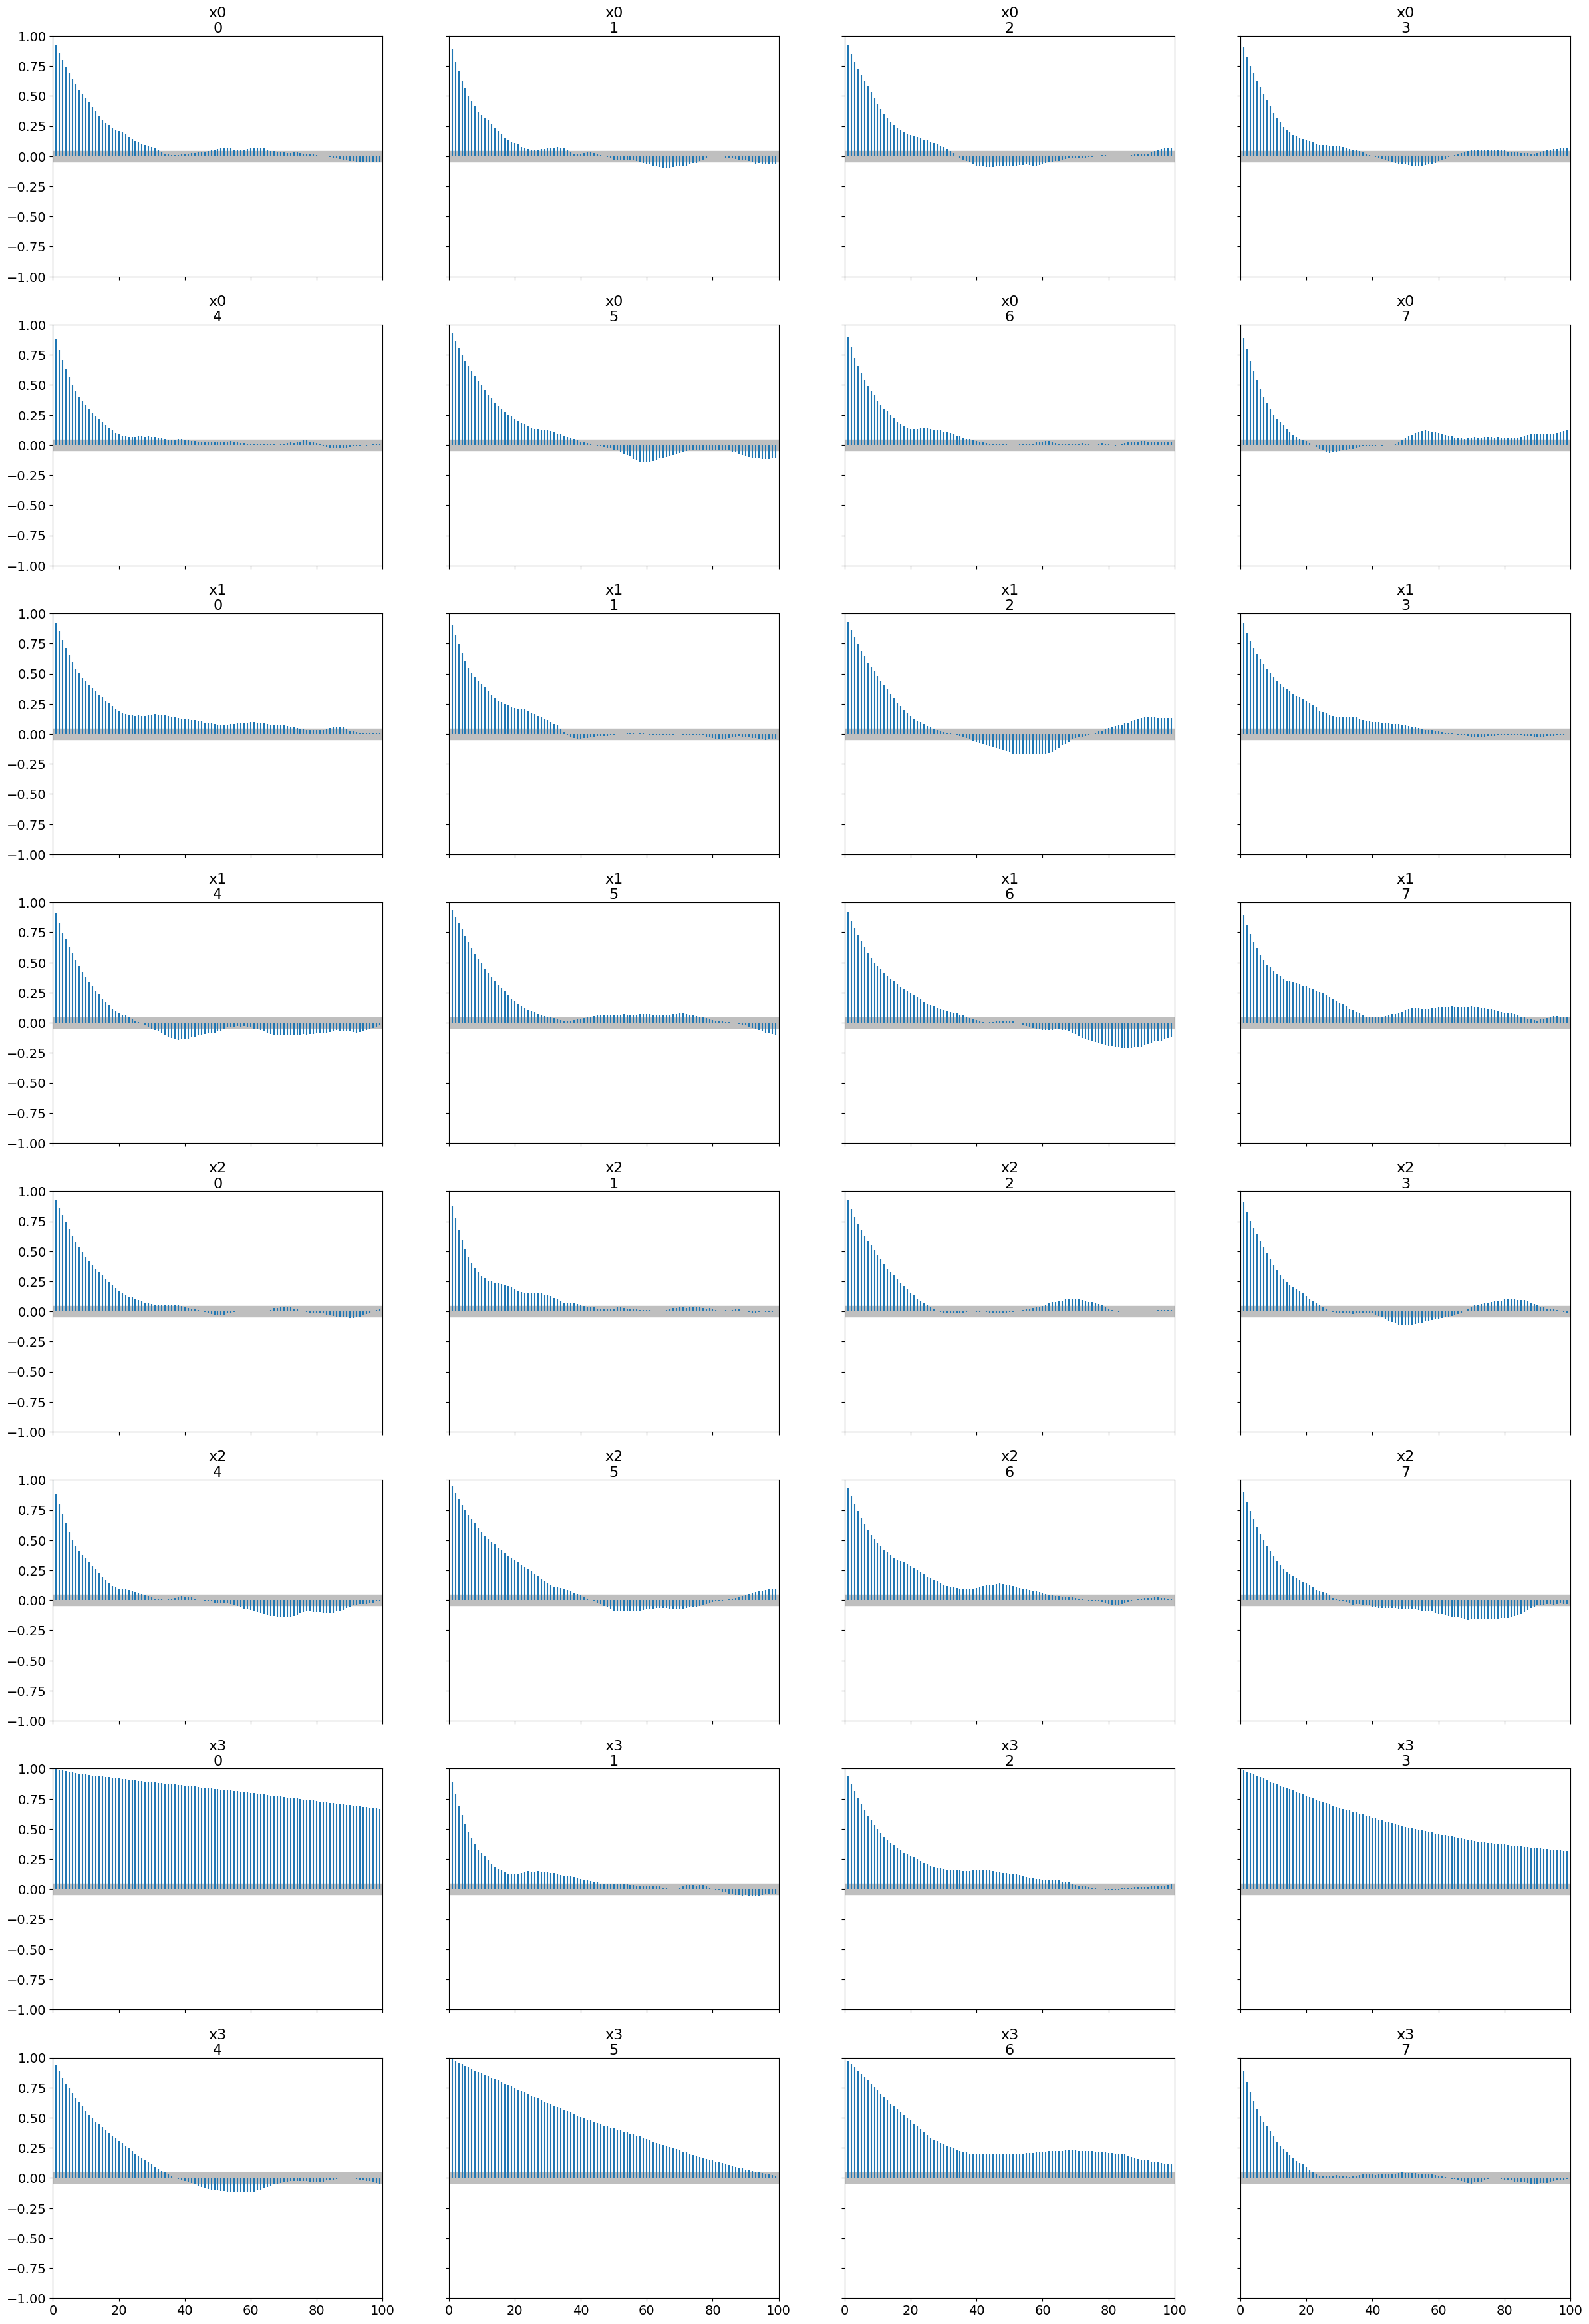

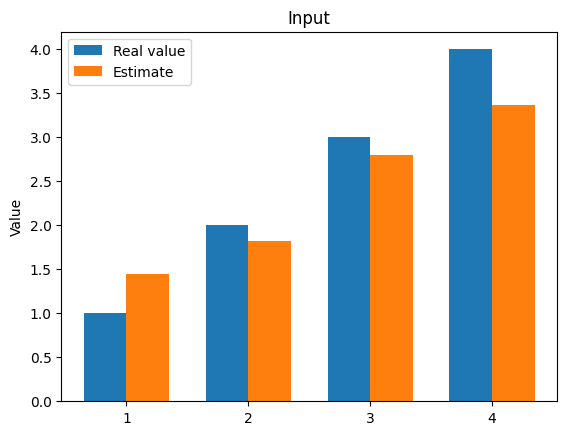

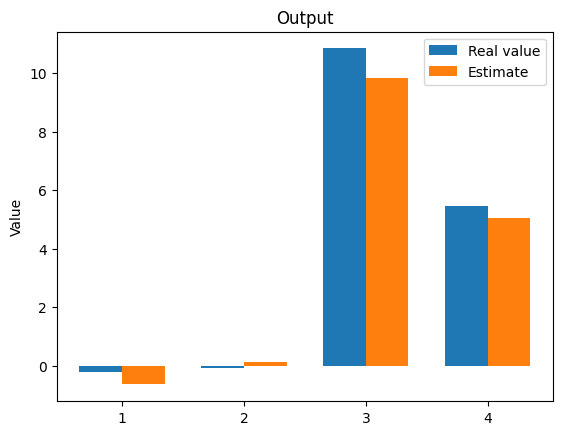

The function inverse took 2680.3795199394226 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.56: 100%|██████████| 4000/4000 [02:50<00:00, 23.47it/s]


Sampling chain 2/8


Running chain, α = 0.56: 100%|██████████| 4000/4000 [02:50<00:00, 23.50it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.68: 100%|██████████| 4000/4000 [02:49<00:00, 23.55it/s]


Sampling chain 8/8


Running chain, α = 0.58: 100%|██████████| 4000/4000 [02:49<00:00, 23.54it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.88  2.851 2.863 2.861]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.880  0.196   2.541    3.213      0.024    0.017      70.0     276.0   
x1  2.851  0.161   2.559    3.120      0.011    0.008     221.0     377.0   
x2  2.863  0.056   2.759    2.968      0.002    0.001    1292.0    1860.0   
x3  2.861  0.073   2.725    3.003      0.002    0.002     917.0    1725.0   

    r_hat  
x0   1.08  
x1   1.03  
x2   1.01  
x3   1.01  
Autocorrelation...
the difference between estimated values [1.88  0.851 0.137 1.139]
 the difference between outputs of two models are [7.3241043  4.9486856  0.08290827 0.4751997 ]


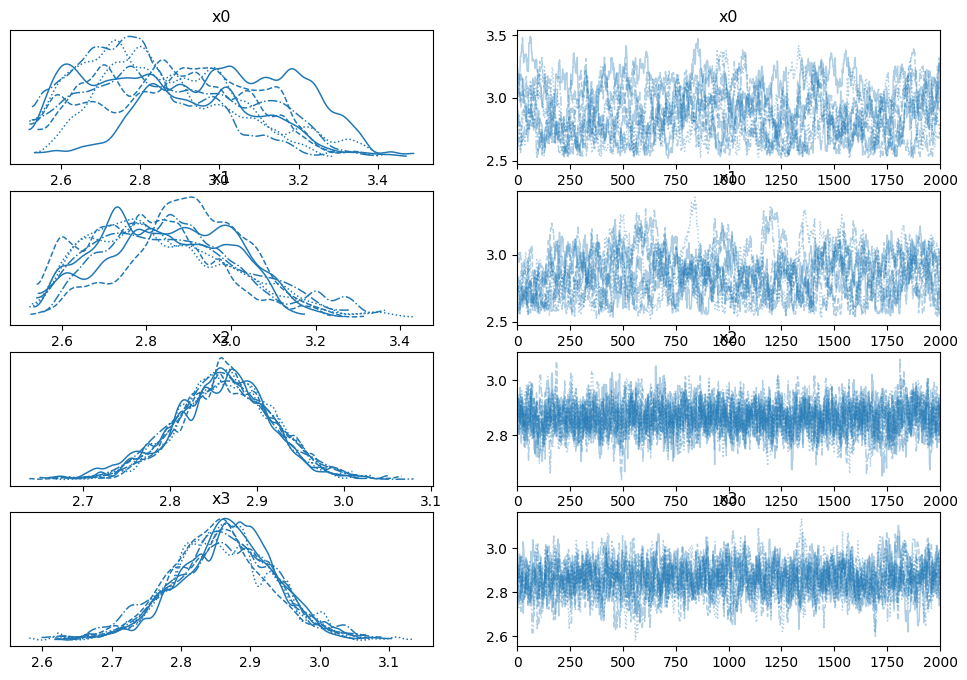

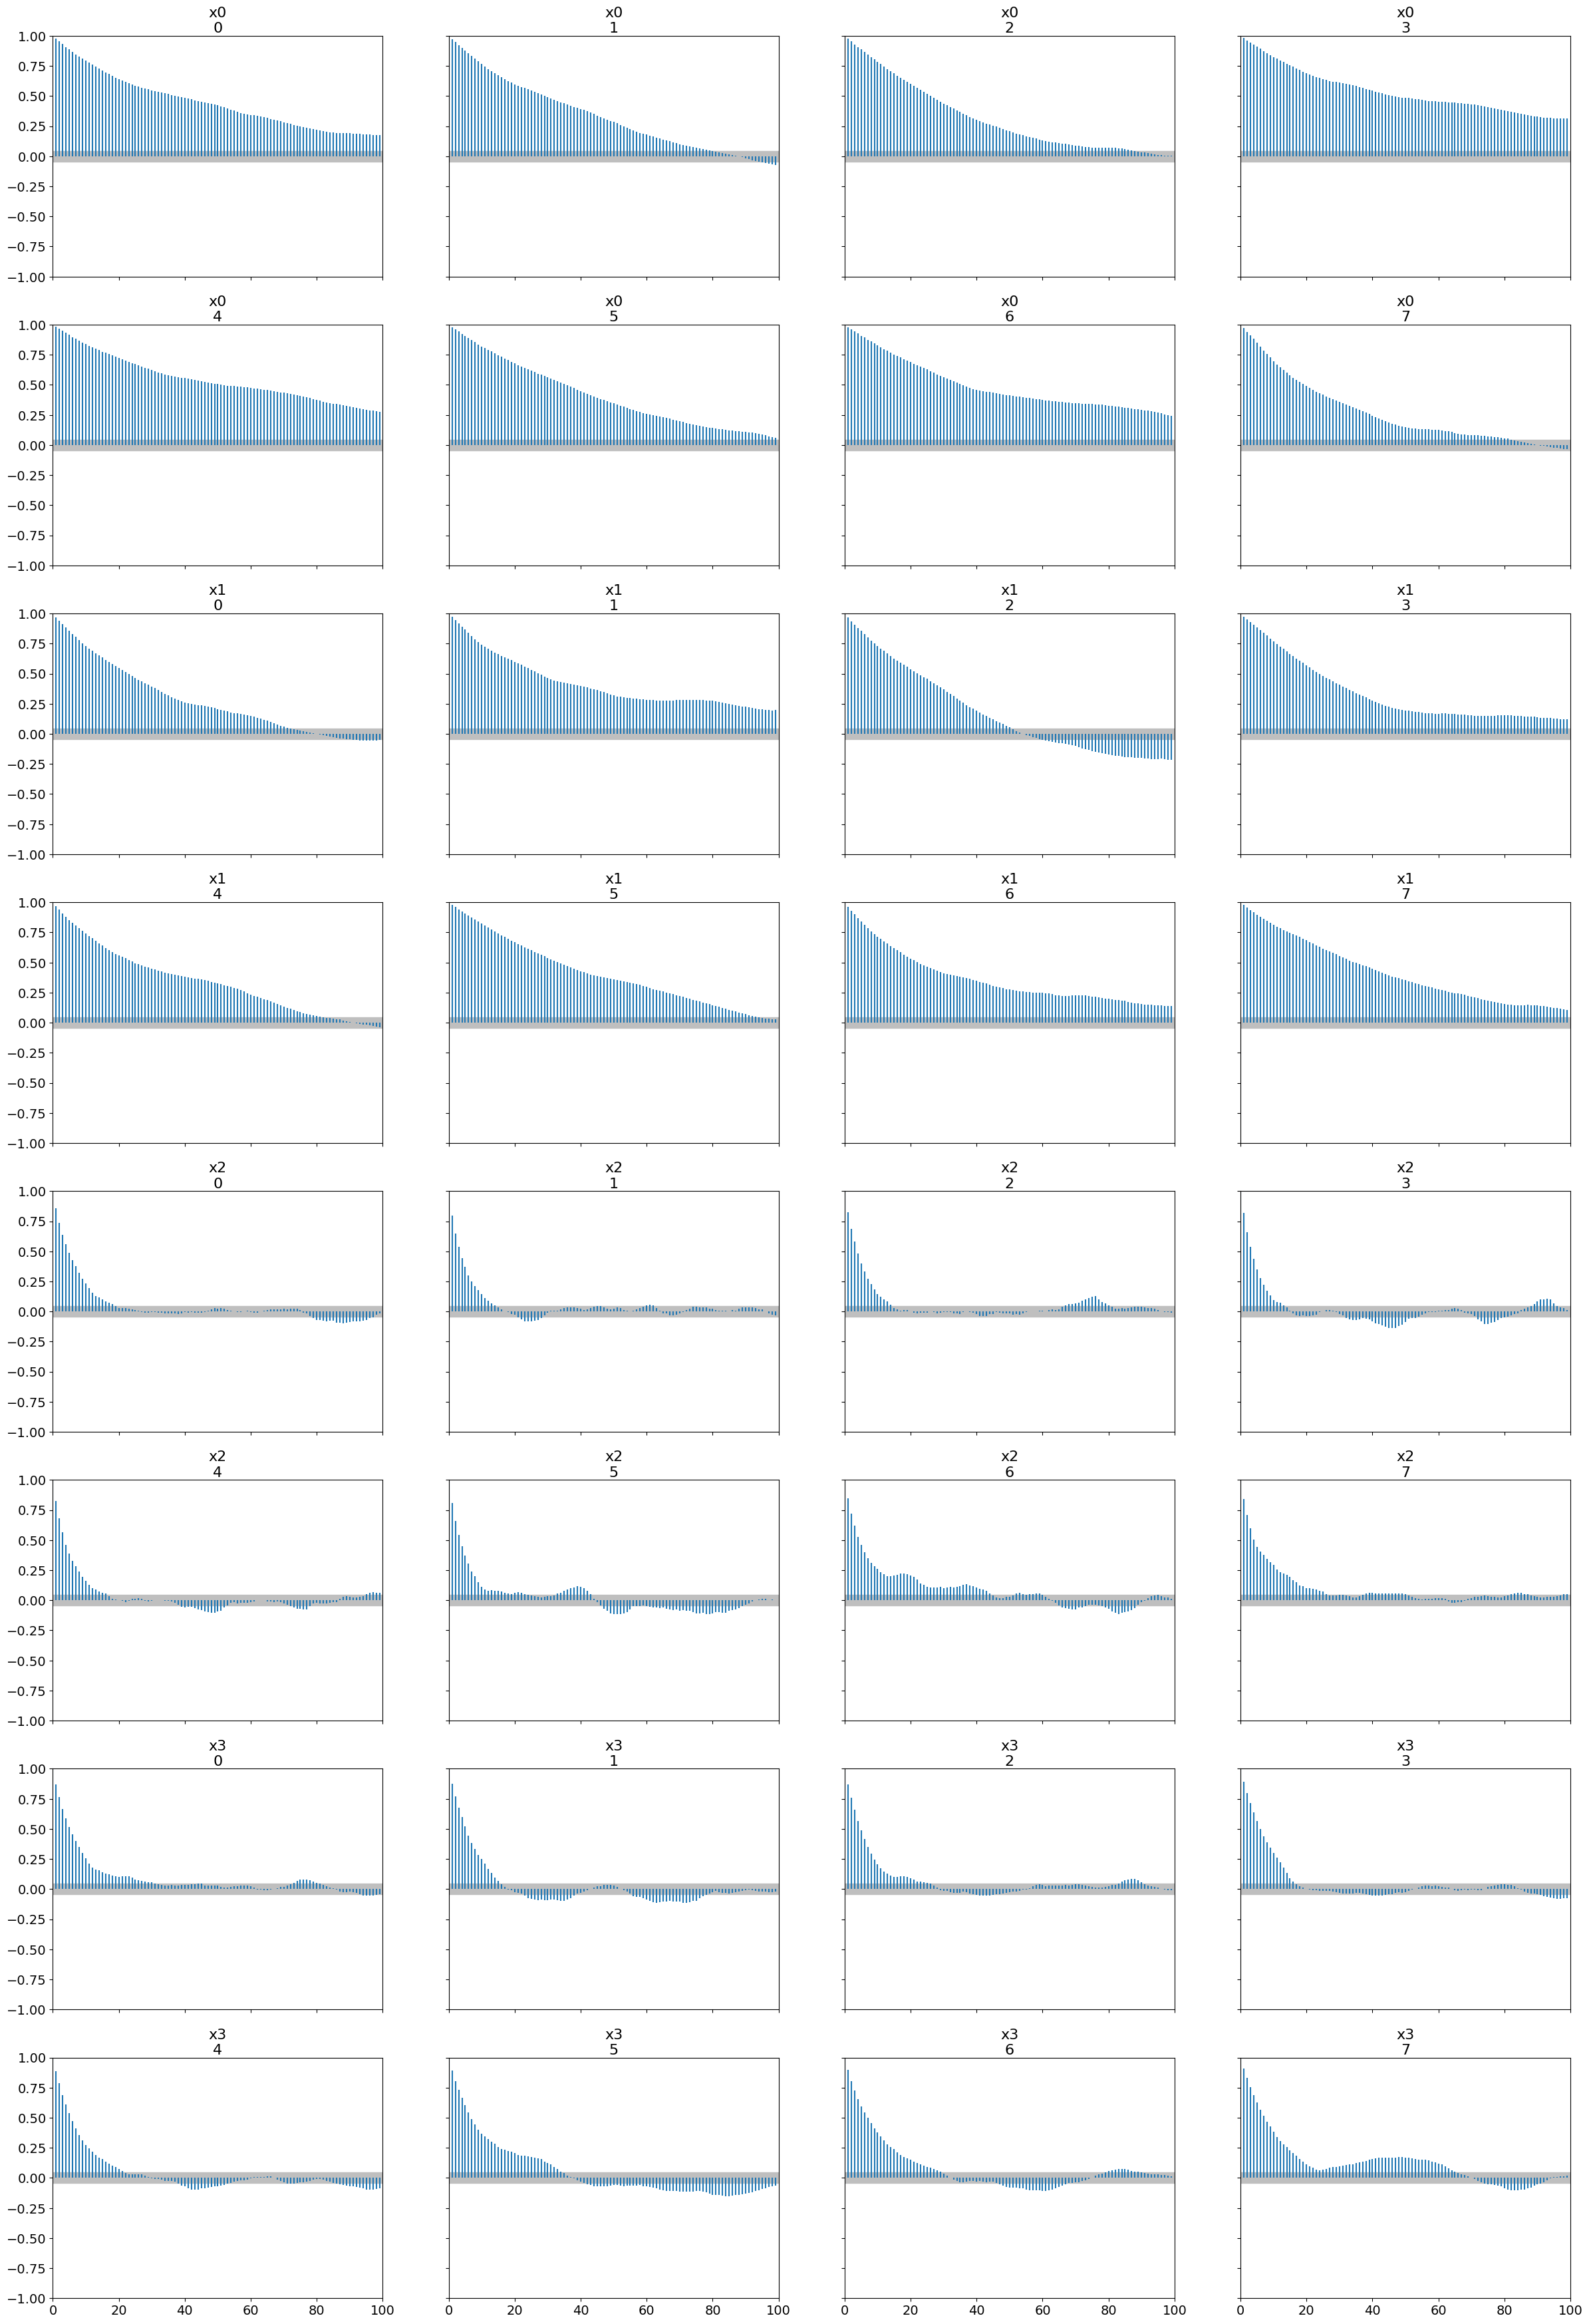

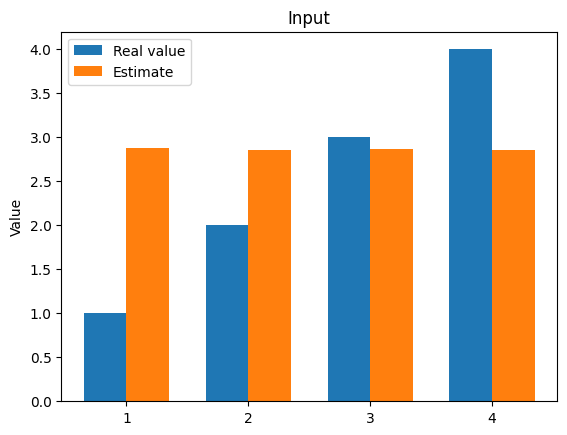

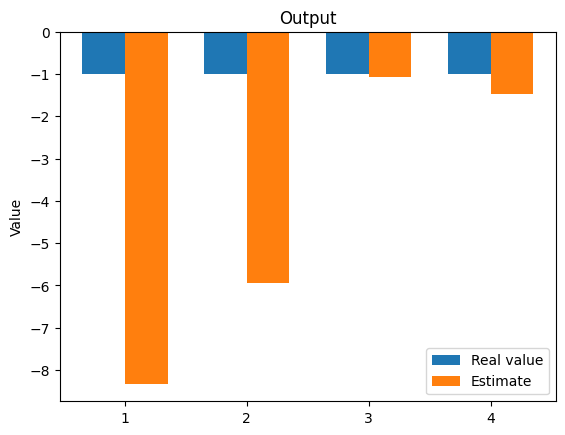

The function inverse took 1364.3051435947418 seconds.
real values are [1. 2. 3. 4.]
Sampling chain 1/8


Running chain, α = 0.79: 100%|██████████| 4000/4000 [02:49<00:00, 23.54it/s]


Sampling chain 2/8


Running chain, α = 0.49: 100%|██████████| 4000/4000 [02:49<00:00, 23.55it/s]


Sampling chain 3/8


...

Sampling chain 7/8


Running chain, α = 0.66: 100%|██████████| 4000/4000 [02:49<00:00, 23.54it/s]


Sampling chain 8/8


Running chain, α = 0.63: 100%|██████████| 4000/4000 [02:50<00:00, 23.53it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [3.921 3.605 2.564 3.826]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.921  0.128   3.714    4.160      0.006    0.005     423.0     869.0   
x1  3.605  0.821   1.443    4.227      0.283    0.207      20.0      22.0   
x2  2.564  1.034  -0.079    3.460      0.353    0.258      17.0      24.0   
x3  3.826  0.210   3.551    4.243      0.018    0.012     164.0     360.0   

    r_hat  
x0   1.01  
x1   1.32  
x2   1.42  
x3   1.05  
Autocorrelation...
the difference between estimated values [2.921 1.605 0.436 0.174]
 the difference between outputs of two models are [5.6897993e+00 5.6572490e+00 8.9697838e-01 4.4274330e-03]


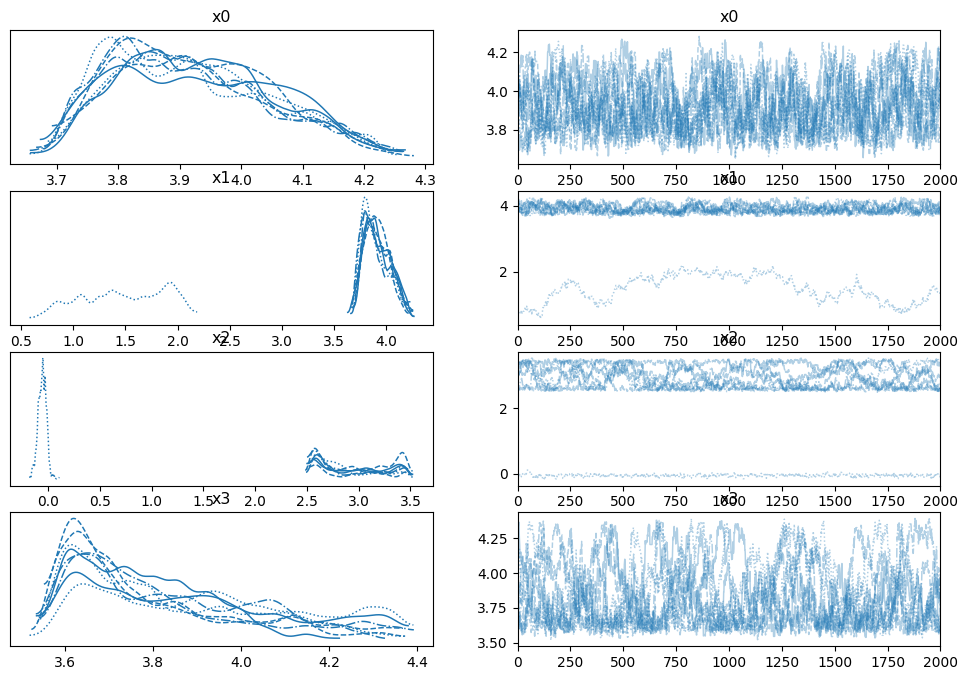

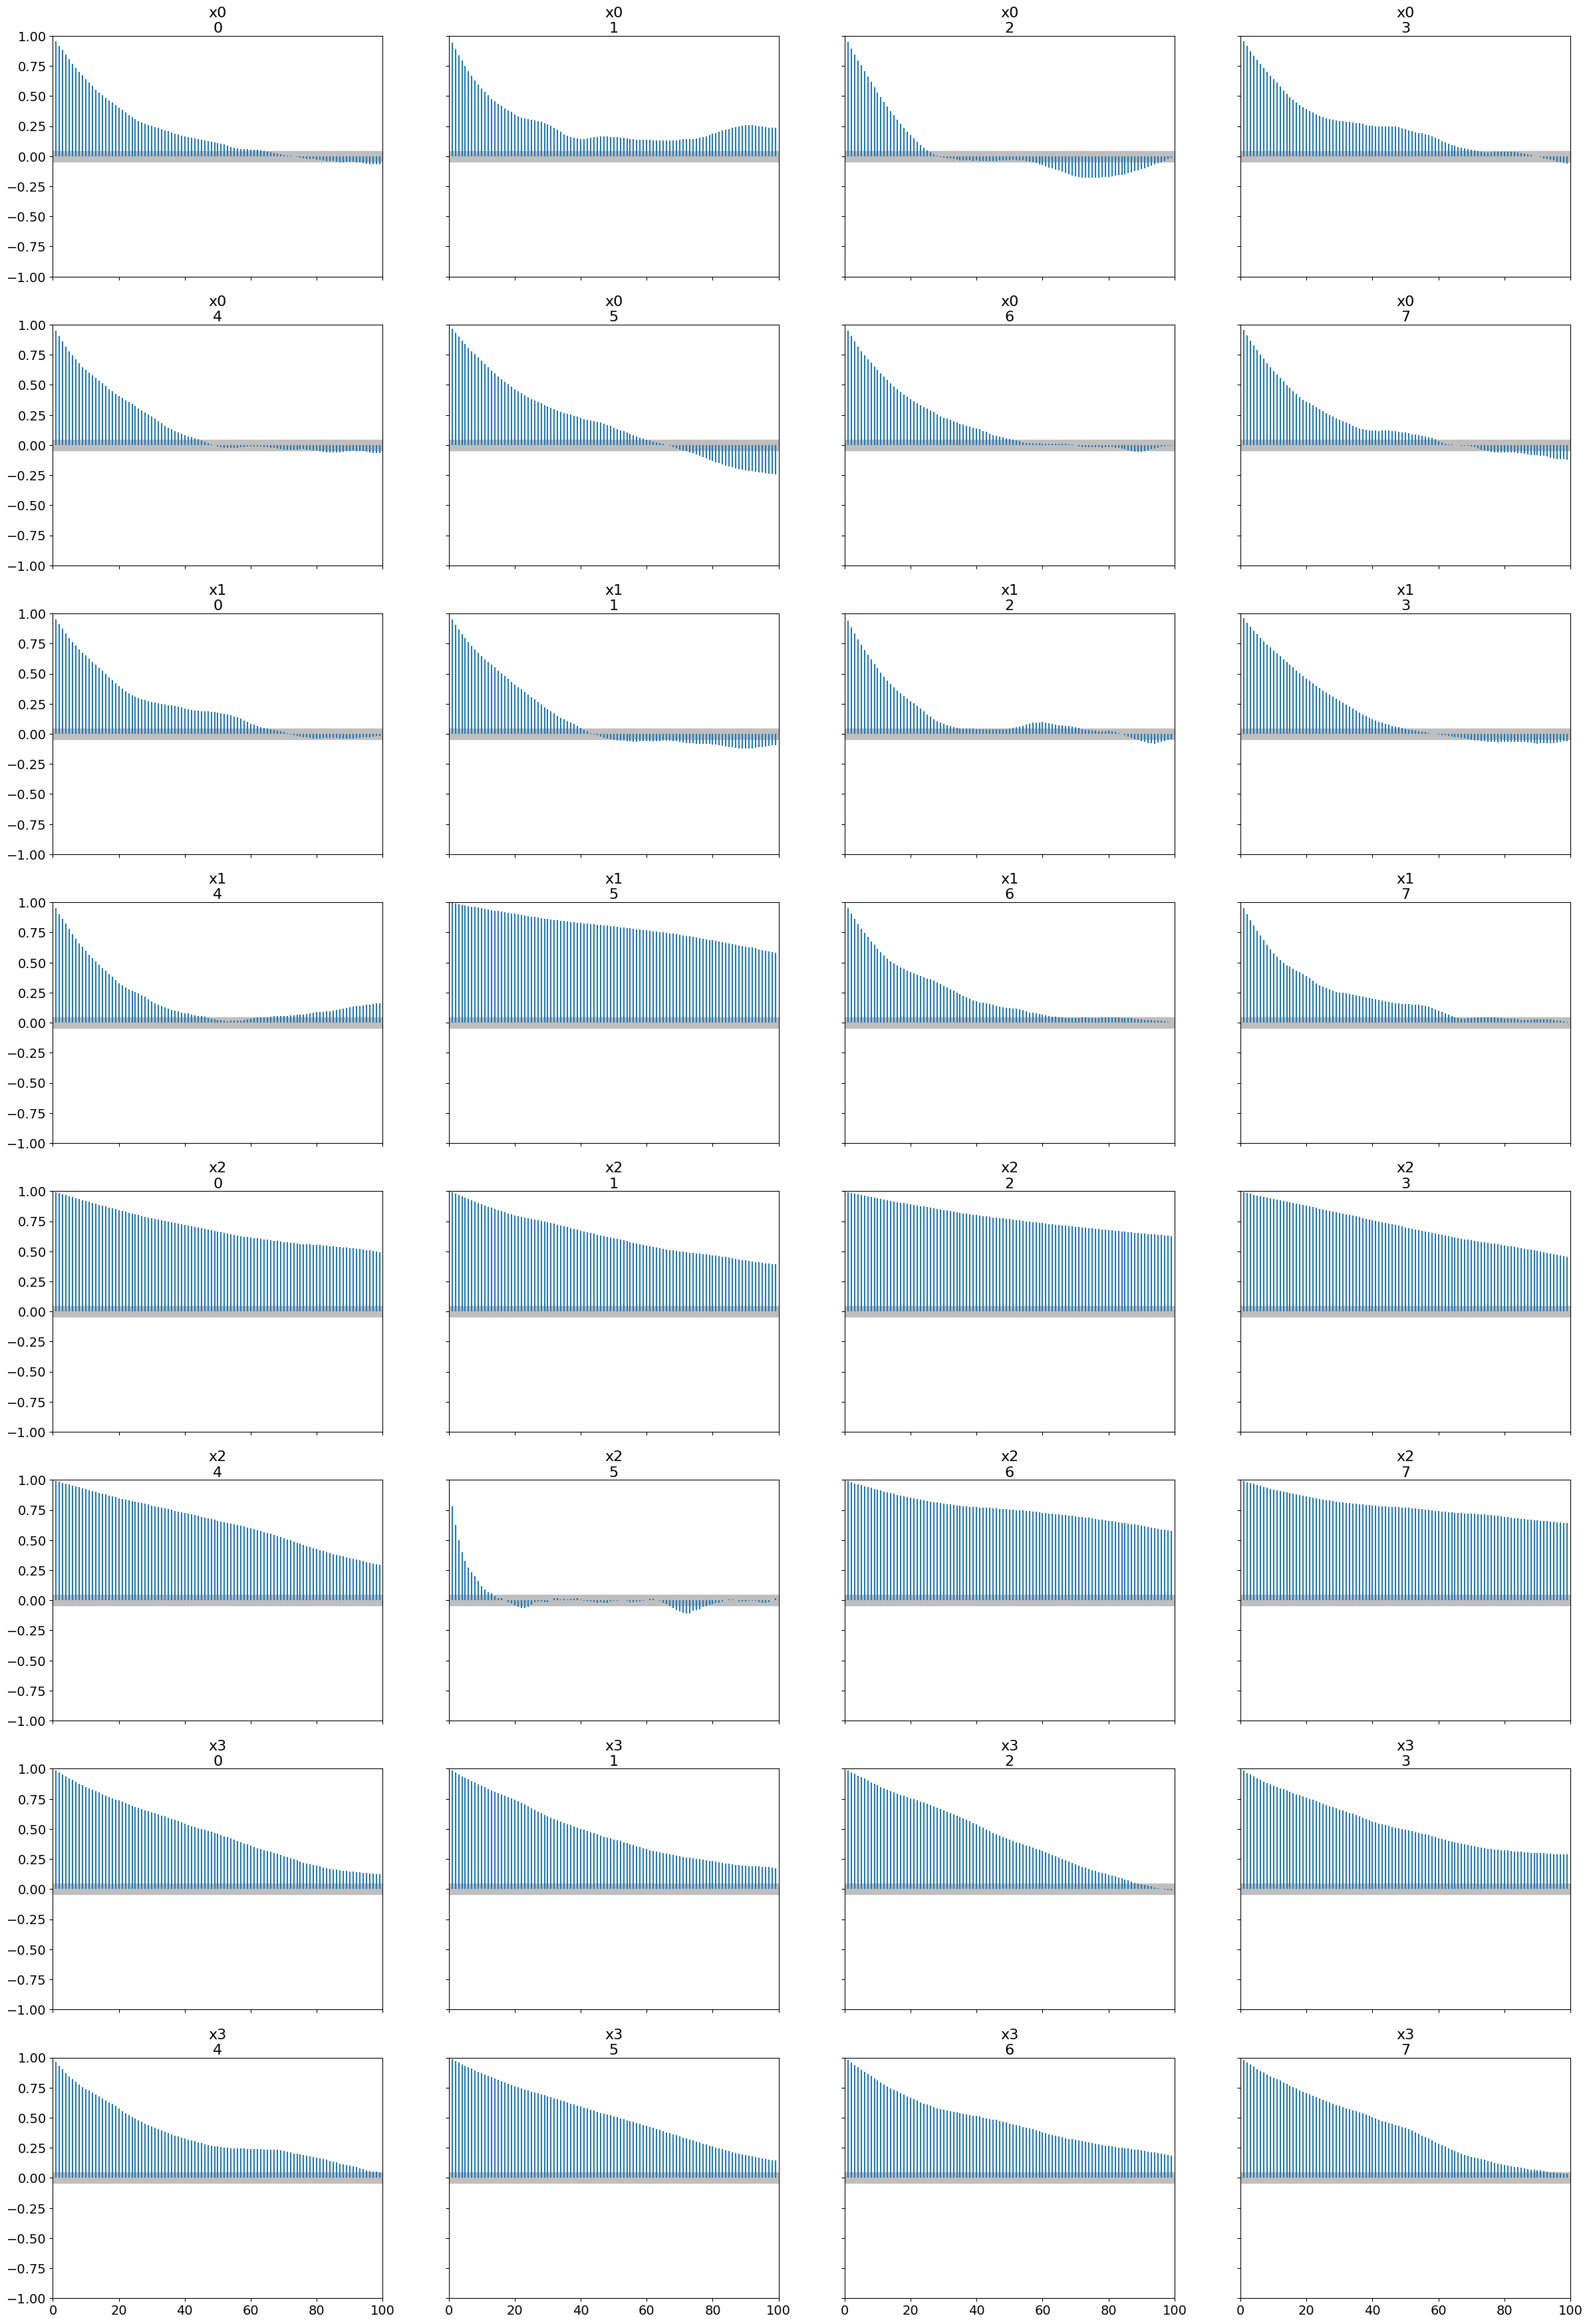

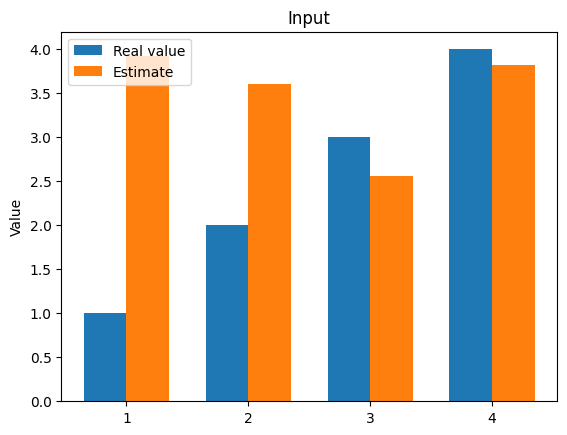

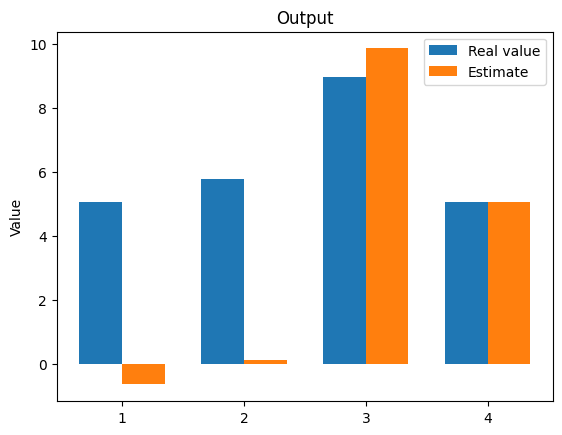

The function inverse took 1374.7530977725983 seconds.


In [23]:
estimate_MF3=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="DREAMZ")
estimate_LF3=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo ="DREAMZ")
estimate_HF3=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive, algo="DREAMZ")

In [13]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.45,0.6])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.2
sigma=0.3
rwmh_cov = np.eye(len(real_x)) *3# !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=2

# Multifidelity

real values are [1.   1.5  2.25 3.  ]
Sampling chain 1/2


Running chain, α = 0.16: 100%|██████████| 2000/2000 [05:08<00:00,  6.49it/s]


Sampling chain 2/2


Running chain, α = 0.26: 100%|██████████| 2000/2000 [05:24<00:00,  6.17it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.5   1.674 1.849 2.997]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.500  0.486   0.617    2.347      0.114    0.082      20.0      58.0   
x1  1.674  0.478   0.681    2.432      0.194    0.144       8.0      11.0   
x2  1.849  0.390   1.270    2.416      0.091    0.065      25.0      19.0   
x3  2.997  0.153   2.553    3.141      0.031    0.022      47.0      35.0   

    r_hat  
x0   1.12  
x1   1.21  
x2   1.05  
x3   1.05  
Autocorrelation...
the difference between estimated values [0.5   0.174 0.401 0.003]
 the difference between outputs of two models are [0.47835082 0.04328346 0.7148205  0.02449036]


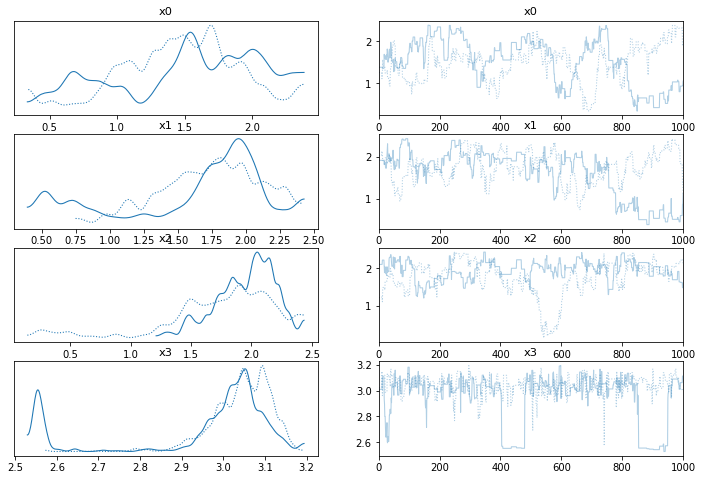

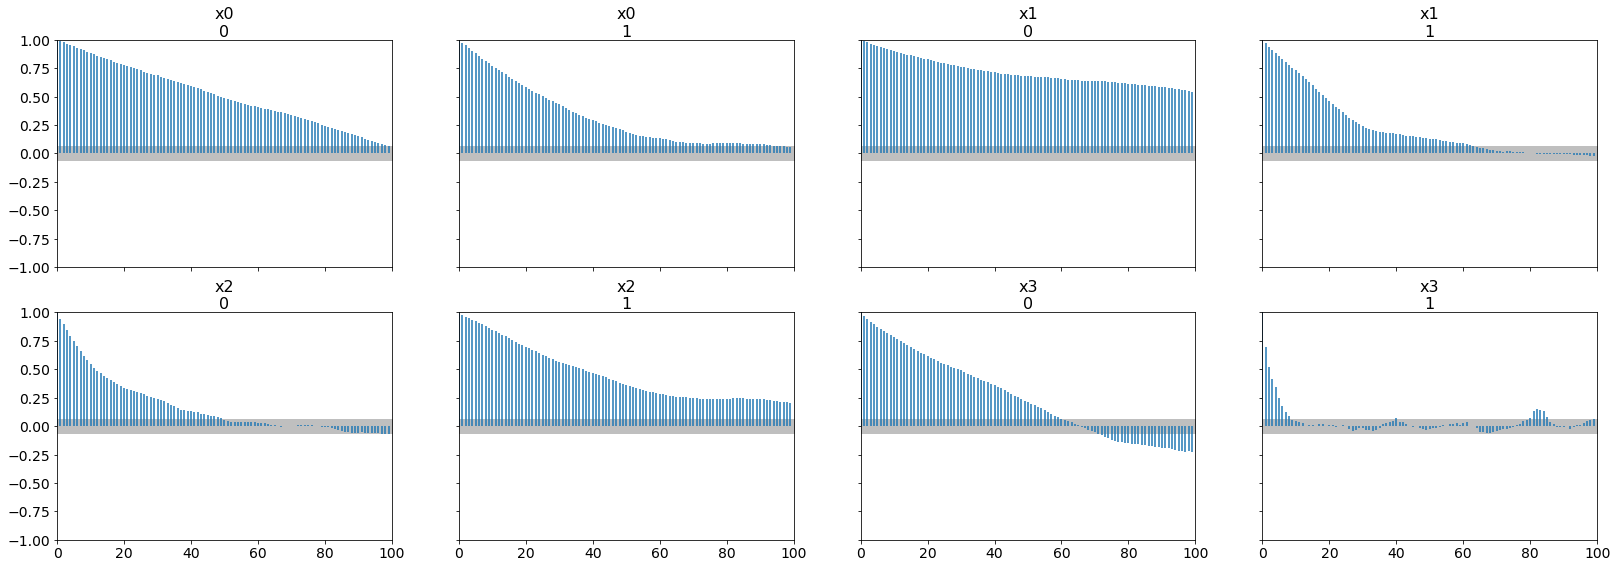

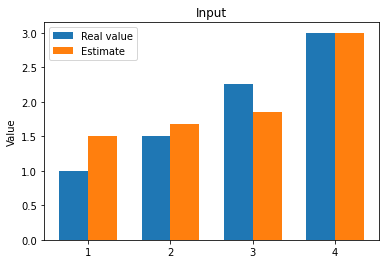

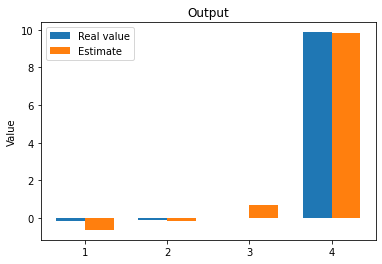

The function inverse took 637.775377035141 seconds.


In [14]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [1.   1.5  2.25 3.  ]


Exception ignored in: <function UniquePtr.__del__ at 0x000001F12A8E2830>
Traceback (most recent call last):
  File "c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\python\framework\c_api_util.py", line 71, in __del__
    obj = self._obj
AttributeError: 'ScopedTFGraph' object has no attribute '_obj'


Sampling chain 1/2


Running chain, α = 0.29: 100%|██████████| 2000/2000 [05:33<00:00,  6.01it/s]


Sampling chain 2/2


Running chain, α = 0.30: 100%|██████████| 2000/2000 [05:16<00:00,  6.31it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.235 1.331 2.128 2.878]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.235  0.472   0.403    1.944      0.121    0.087      17.0      62.0   
x1  1.331  0.507   0.419    2.086      0.113    0.084      20.0      56.0   
x2  2.128  0.318   1.415    2.439      0.086    0.063      16.0      71.0   
x3  2.878  0.177   2.545    3.060      0.025    0.018      67.0     105.0   

    r_hat  
x0   1.16  
x1   1.07  
x2   1.10  
x3   1.03  
Autocorrelation...
the difference between estimated values [0.235 0.169 0.122 0.122]
 the difference between outputs of two models are [0.29841137 0.1036917  0.29651862 0.79768944]


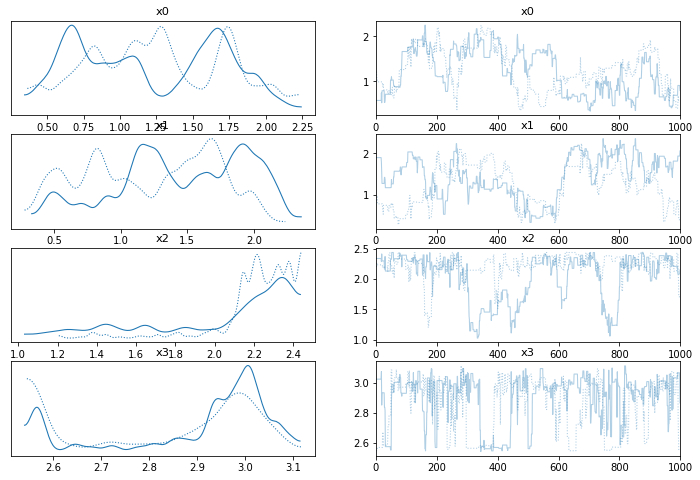

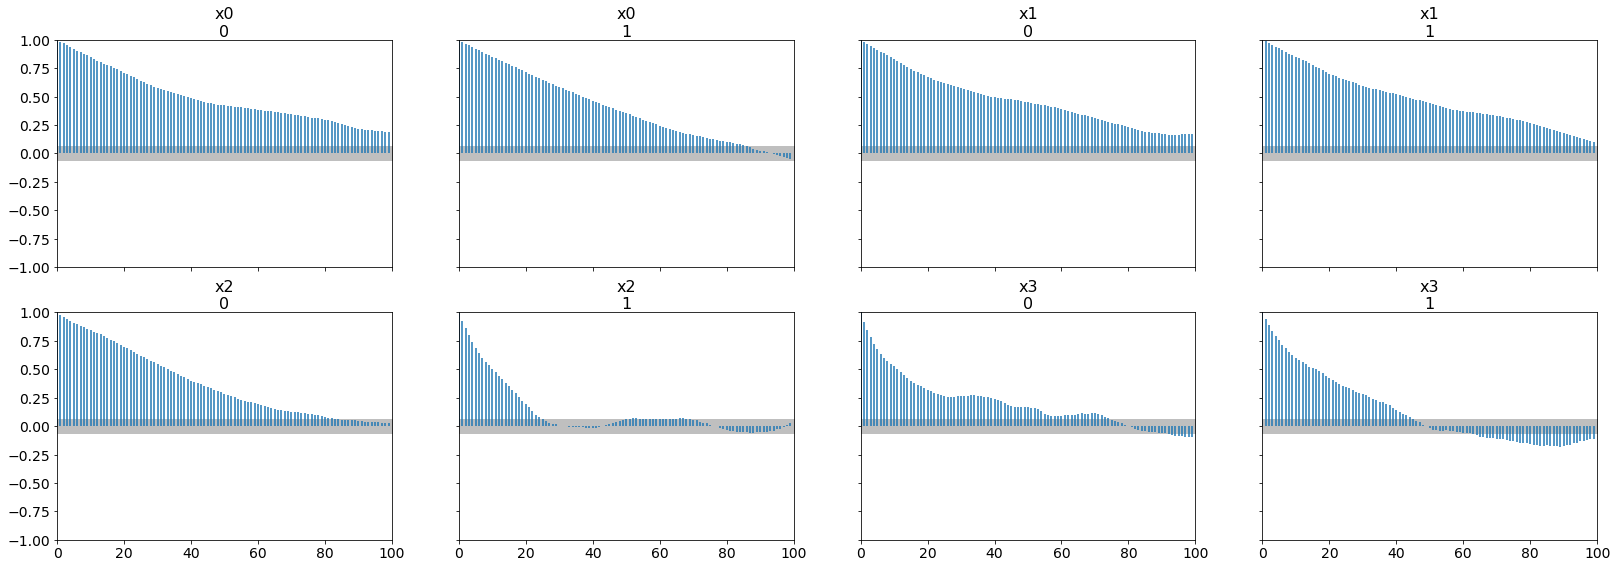

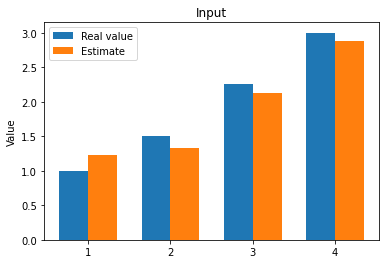

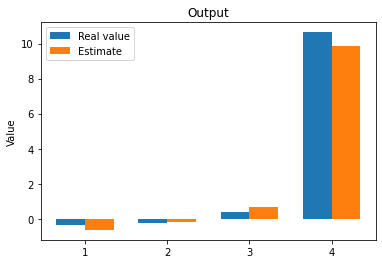

The function inverse took 754.988499879837 seconds.


In [18]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.45,0.6])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.5
sigma=0.5
rwmh_cov = np.eye(len(real_x)) *3# !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =2000
burnin = 1000
n_chains=2
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

### Low Fidelity

real values are [1.   1.5  2.25 3.  ]
Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 2000/2000 [03:08<00:00, 10.59it/s]


Sampling chain 2/2


Running chain, α = 0.15: 100%|██████████| 2000/2000 [04:28<00:00,  7.45it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [3.526 3.449 2.877 2.857]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.526  0.659   2.652    4.306      0.457    0.386       3.0      63.0   
x1  3.449  0.626   2.641    4.246      0.413    0.342       3.0      88.0   
x2  2.877  0.147   2.598    3.092      0.018    0.013      69.0      77.0   
x3  2.857  0.076   2.711    2.993      0.006    0.005     138.0     156.0   

    r_hat  
x0   1.87  
x1   1.68  
x2   1.05  
x3   1.02  
Autocorrelation...
the difference between estimated values [2.526 1.949 0.627 0.143]
 the difference between outputs of two models are [5.9638467  4.8423195  4.256404   0.06907105]


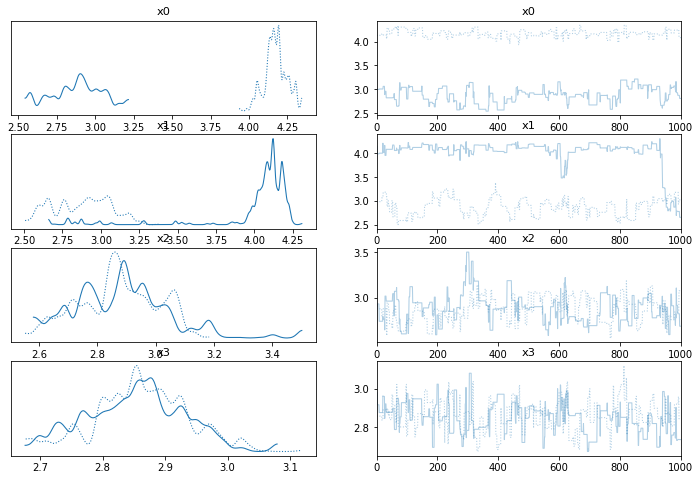

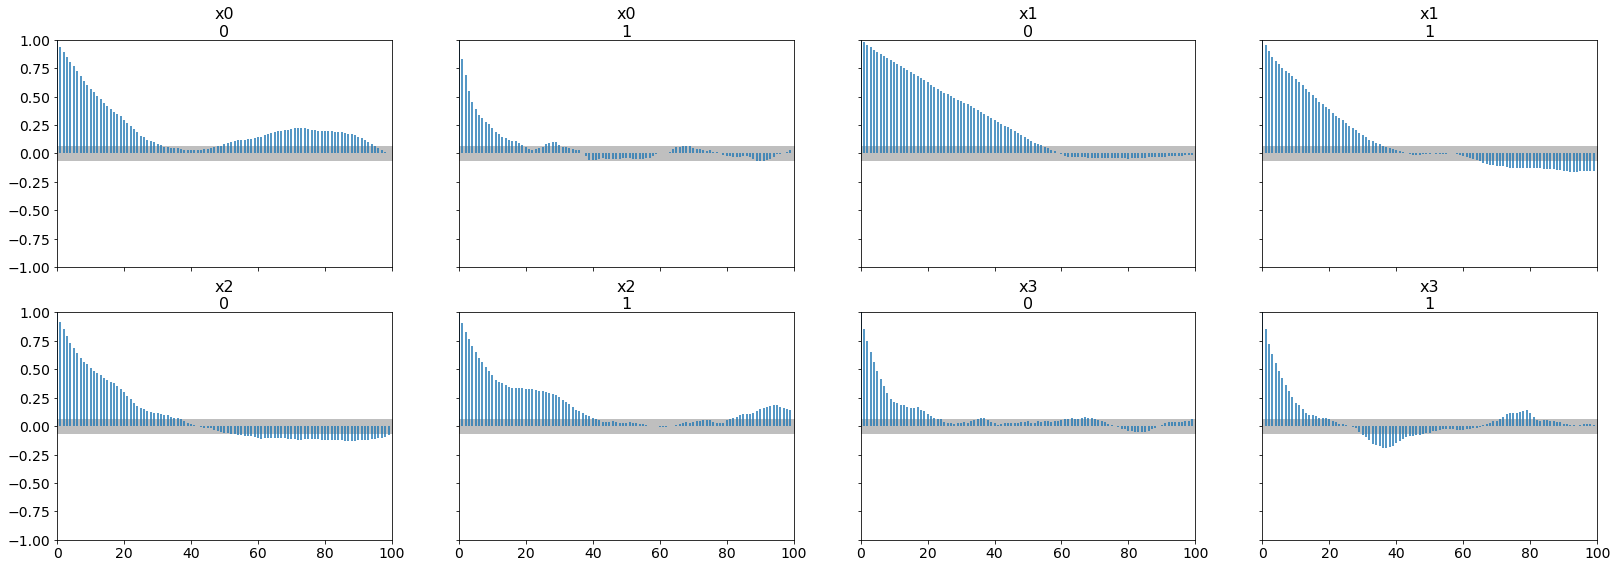

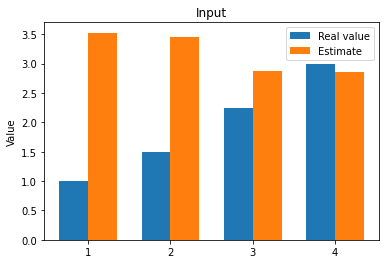

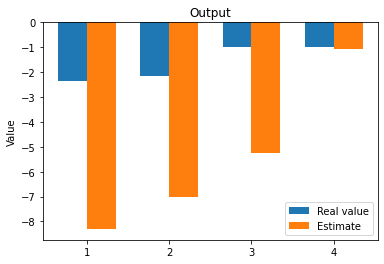

The function inverse took 474.98948073387146 seconds.


In [19]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


In [ ]:
## High Fidelity

In [20]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


real values are [1.   1.5  2.25 3.  ]
